<a href="https://colab.research.google.com/github/nkcrooks/Movie-Analysis---Python/blob/main/notebooks/02_trakt_exploratory_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Loading Data & Packages

In [3]:
# Packages
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mpl_dates
import seaborn as sns
import numpy as np
import plotly.express as px
from matplotlib.ticker import FuncFormatter
from pathlib import Path
# !pip install pyarrow
import pyarrow as pa
# !pip install fastparquet
from fastparquet import ParquetFile
import sys

In [4]:
# Add the project root to sys.path
sys.path.append(str(Path().resolve().parent))

# Set folder path
root_path = Path().resolve().parent
file_path=root_path/"data" / "processed" 

# Get all PARQ files
parq_files = list(file_path.glob('*.parq*'))
dfs = {file.stem: pd.read_parquet(file) for file in parq_files}

# Example: Access the DataFrame for a specific file
df = pd.DataFrame(dfs['cleaned_enriched_movies'])

In [5]:
df = pd.DataFrame(dfs['cleaned_enriched_movies'])
df_genres = pd.DataFrame(dfs['cleaned_enriched_movies_genres'])
df_directors = pd.DataFrame(dfs['cleaned_enriched_movies_directors'])
df_actors = pd.DataFrame(dfs['cleaned_enriched_movies_actors'])
df_country = pd.DataFrame(dfs['cleaned_enriched_movies_country'])

In [6]:
pd.set_option("styler.format.thousands", ",")

## Exploratory Data Analysis


In [7]:
taylor = df['Viewer']=='taylor'
nowell = df['Viewer']=='nowell'

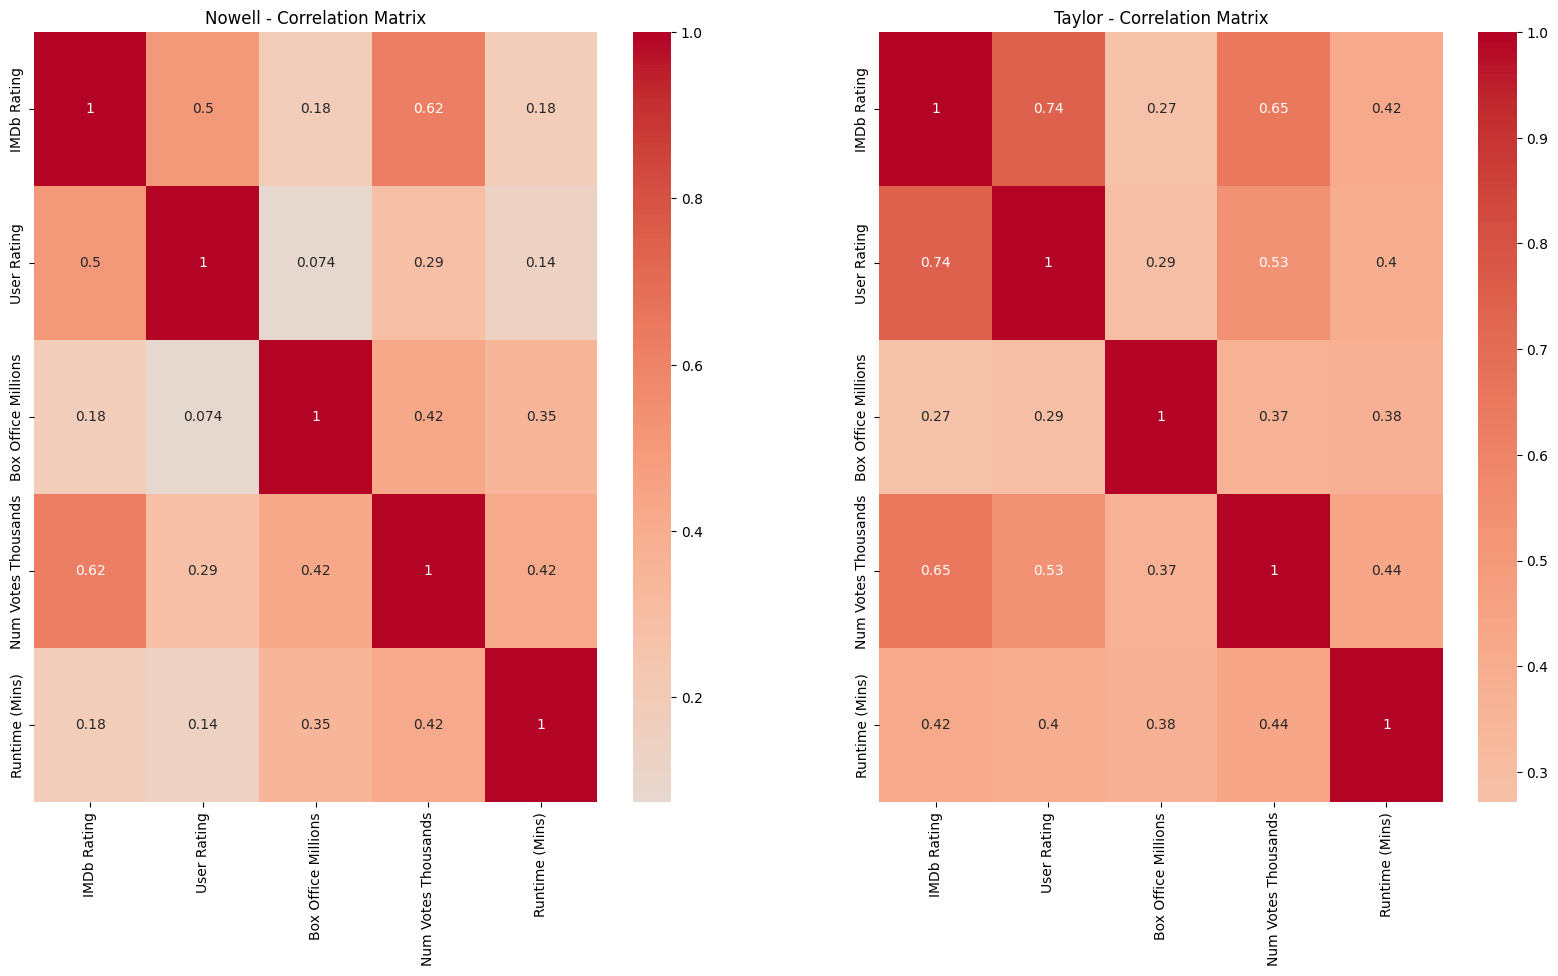

In [8]:
corr_matrix_1 = df[nowell].iloc[:,:10].corr(numeric_only = True)
corr_matrix_2 = df[taylor].iloc[:,:10].corr(numeric_only = True)

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(40, 15))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

sns.heatmap(corr_matrix_1, annot=True, cmap='coolwarm', center=0, ax=ax1)
sns.heatmap(corr_matrix_2, annot=True, cmap='coolwarm', center=0, ax=ax2)
ax1.set_title('Nowell - Correlation Matrix')
ax2.set_title('Taylor - Correlation Matrix')
plt.show()

Seems to be less correlation for me than IMDb average. Suggests I'm not swayed by popularity. Strong corr for IMDb, weak for me. Weak correlation for both me and Taylor with IMDb rating.

### Nowell VS Taylor VS IMDb
Most loved/hated movies?


#### By Genre

Most popular genres

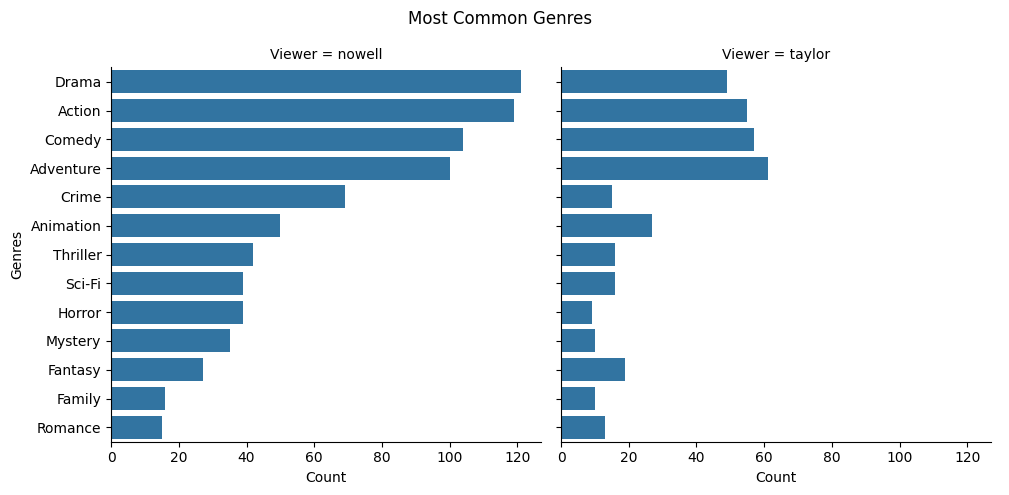

In [9]:
min_count = 5

# Count the number of ratings per genre
genre_counts = df_genres['Genres'].value_counts()

# Filter genres with counts above the threshold
valid_genres = genre_counts[genre_counts >= min_count].index
filtered_df = df_genres[df_genres['Genres'].isin(valid_genres)]

genre_ratings = filtered_df.groupby(['Genres','Viewer']).agg({
    'User Rating':'mean',
    # 'User Rating': 'sum',
    'IMDb Rating':'mean',
    'Genres':'count'
}).rename(columns={'Genres': 'Count'}).sort_values(by =['Count','User Rating'], ascending = False)

genre_ratings.reset_index(inplace=True)

f=sns.catplot(
    data=genre_ratings,
    y='Genres', x='Count',
    kind='bar',
    col='Viewer', order = genre_ratings.sort_values(by='Count', ascending=False)['Genres'][:25],
    sharex=True
    )

# common axis labels
f.fig.suptitle('Most Common Genres')
# f.fig.supxlabel('Count')
plt.tight_layout()
plt.show()

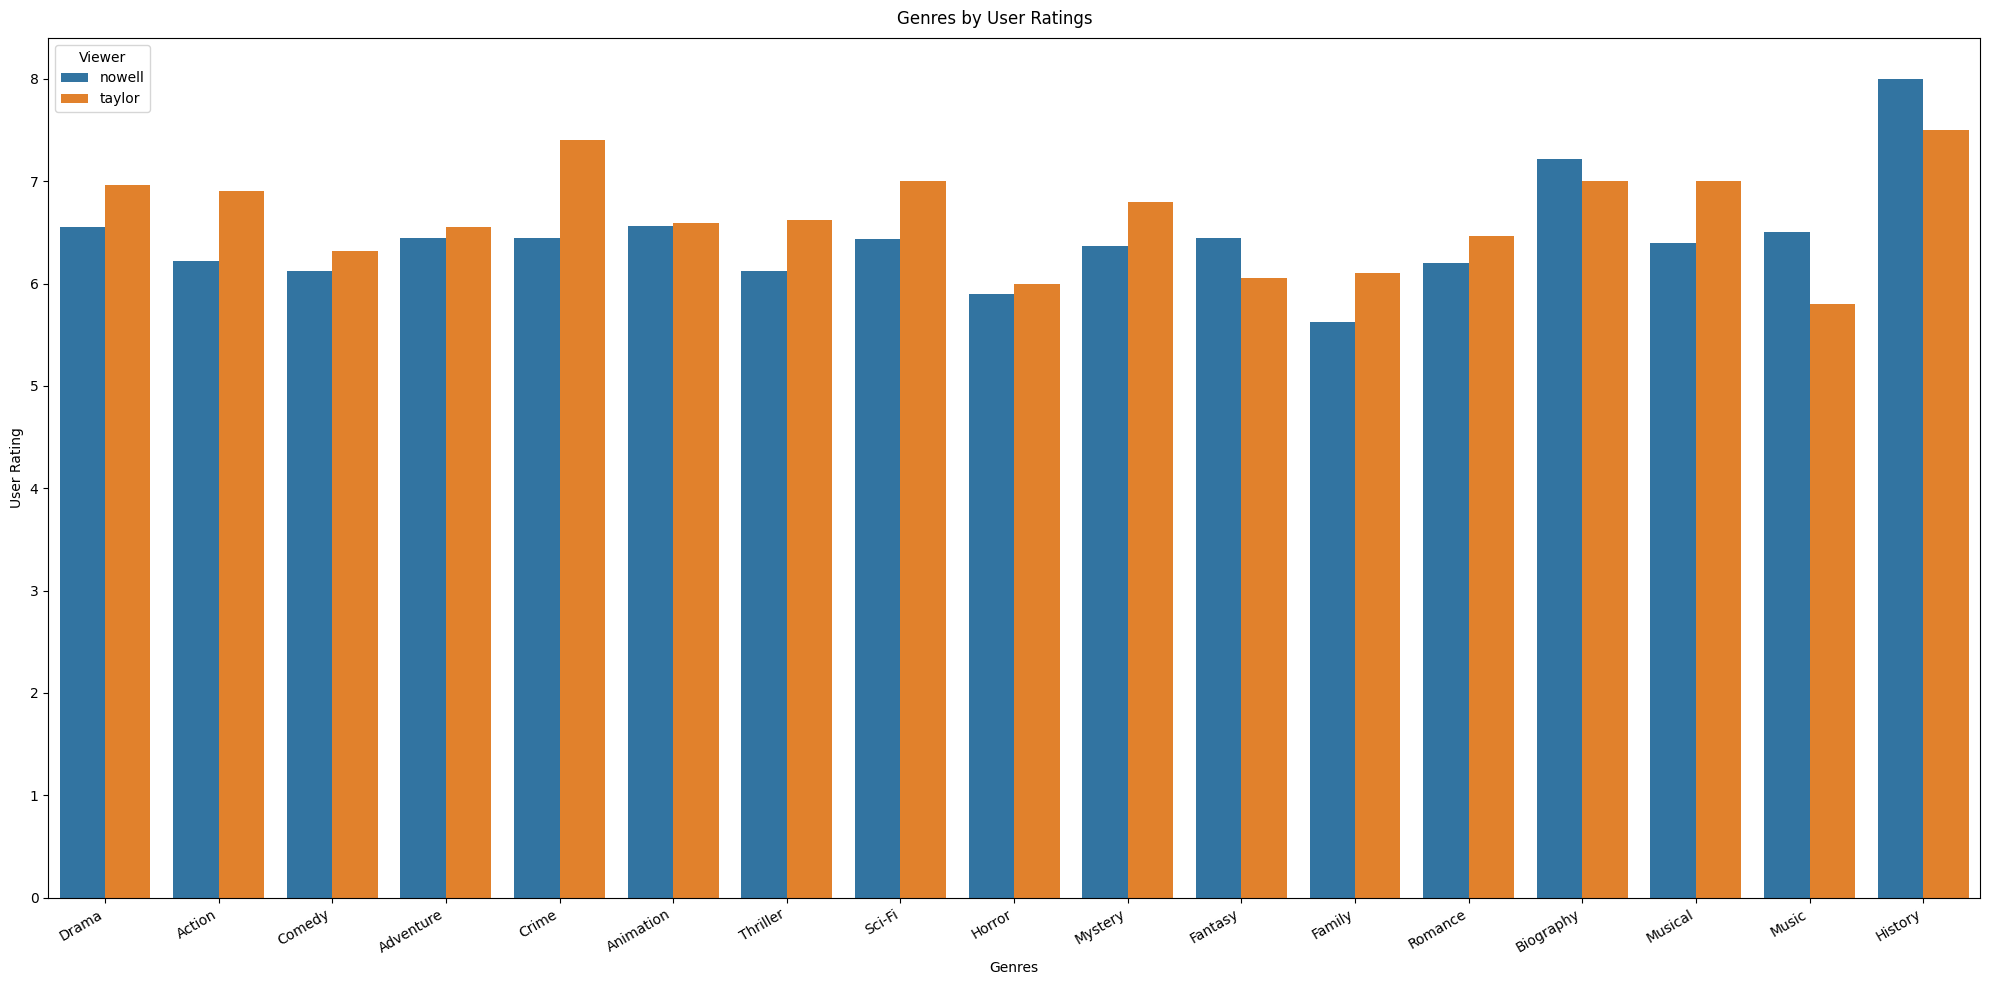

In [10]:
fig, ax=plt.subplots(figsize=(20, 10))
g=sns.barplot(data=genre_ratings.sort_values(by='Count',ascending=False),
              x='Genres', y='User Rating',
              hue='Viewer')
fig.autofmt_xdate()
# common axis labels
fig.suptitle('Genres by User Ratings')
# g.fig.supxlabel('Genres')
plt.tight_layout()
plt.show()

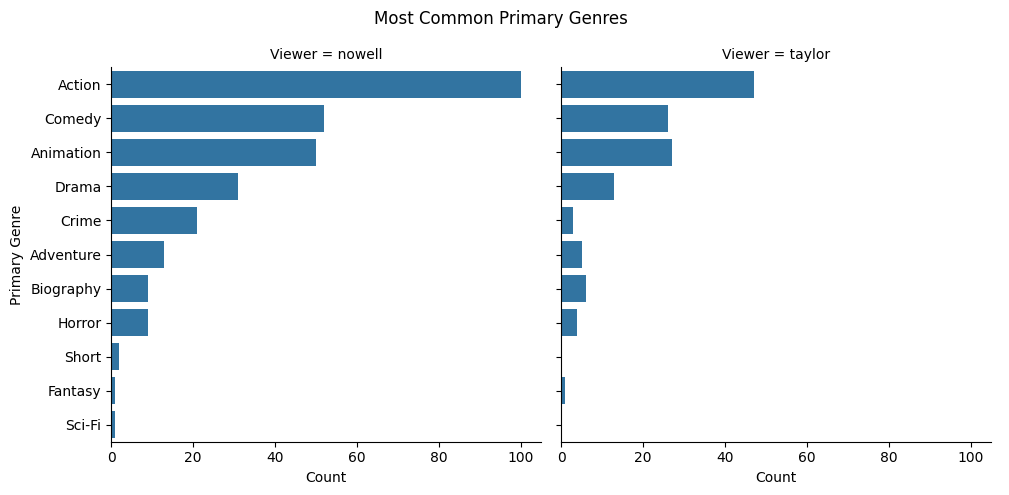

In [11]:
primary_genre_ratings = df.groupby(['Primary Genre','Viewer']).agg({
    'User Rating':'mean',
    'IMDb Rating':'mean',
    'Primary Genre':'count'
}).rename(columns={'Primary Genre': 'Count'}).sort_values(by =['Count','User Rating'], ascending = False)

primary_genre_ratings.reset_index(inplace=True)
primary_genre_ratings

g=sns.catplot(data =primary_genre_ratings,
            col='Viewer', kind='bar',
            y='Primary Genre', x='Count',
            order = primary_genre_ratings.sort_values(by='Count', ascending=False)['Primary Genre'][:20])

# common axis labels
g.fig.suptitle('Most Common Primary Genres')
# g.fig.supxlabel('Count')
plt.tight_layout()
plt.show()

In [12]:
genre_ratings_1=genre_ratings.loc[genre_ratings['Viewer']=='nowell']
genre_ratings_2=genre_ratings.loc[genre_ratings['Viewer']=='taylor']

top_genres_1=zip(genre_ratings_1['Count'][:4],genre_ratings_1['Genres'][:4])
top_genres_1 = dict(top_genres_1)
top_genres_2 =zip(genre_ratings_1['Count'][:4],genre_ratings_1['Genres'][:4])
top_genres_1 = dict(top_genres_1)

uncommon_genres_1=zip(genre_ratings_1['Count'][4:],genre_ratings_1['Genres'][4:])
uncommon_genres_1 = dict(uncommon_genres_1)

uncommon_genres_2=zip(genre_ratings_2['Count'][4:],genre_ratings_2['Genres'][4:])
uncommon_genres_2 = dict(uncommon_genres_2)

print('Nowell Top Genres:', top_genres_1)
print('Taylor Top Genres:', top_genres_2)

print('Nowell Uncommon Genres:', uncommon_genres_1)
print('Taylor Uncommon Genres:', uncommon_genres_2)

Nowell Top Genres: {121: 'Drama', 119: 'Action', 104: 'Comedy', 100: 'Adventure'}
Taylor Top Genres: <zip object at 0x00000248533B7800>
Nowell Uncommon Genres: {69: 'Crime', 50: 'Animation', 42: 'Thriller', 39: 'Horror', 35: 'Mystery', 27: 'Fantasy', 16: 'Family', 15: 'Romance', 9: 'Biography', 5: 'Musical', 4: 'Music', 3: 'History'}
Taylor Uncommon Genres: {27: 'Animation', 19: 'Fantasy', 16: 'Thriller', 15: 'Crime', 13: 'Romance', 10: 'Family', 9: 'Horror', 6: 'Biography', 5: 'Music', 4: 'Musical', 2: 'History'}


Our graphs are very similar suggesting a similar taste in genres. Almost perfect correlation of genres. Perhaps there's a confounding variable like the genres action, drama and adventure being vague enough to apply to any film.

In [13]:
## Calculate correlation between me and Taylor

#### By Actor & Director

Text(0.5, 0.98, 'Most Common Actors')

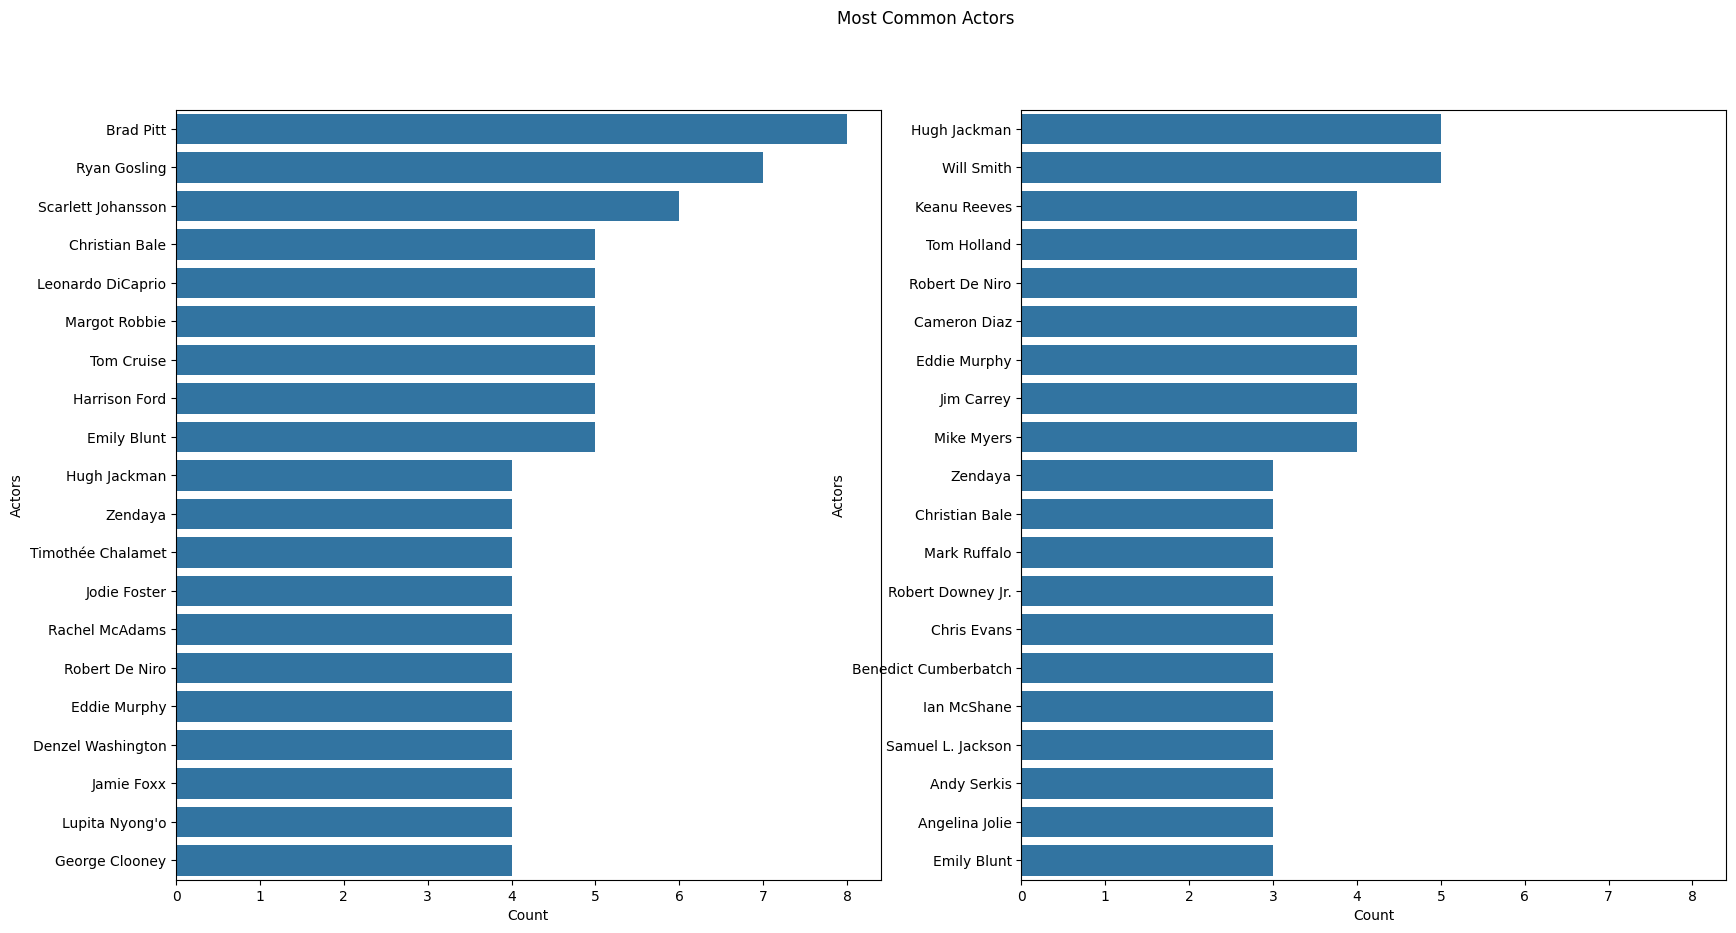

In [14]:
actor_summary = df_actors.groupby(['Actors','Viewer']).agg({
    'User Rating': 'mean',
    'IMDb Rating': 'mean',
    'Actors': 'count'
}).rename(columns={'Actors': 'Count'}).sort_values(by=['Count', 'User Rating'], ascending=False)

actor_summary.reset_index(inplace=True)

actor_summary_1 = actor_summary.loc[actor_summary['Viewer']=='nowell']
actor_summary_2 = actor_summary.loc[actor_summary['Viewer']=='taylor']

fig, (ax1, ax2) = plt.subplots(1,2 ,figsize=(20, 10), sharex=True)
f=sns.barplot(data=actor_summary_1,
              y='Actors', x='Count',
              ax=ax1,
              order = actor_summary_1.sort_values(by='Count', ascending=False)['Actors'][:20],
              )
g=sns.barplot(data=actor_summary_2,
              y='Actors', x='Count',
              ax=ax2,
              order = actor_summary_2.sort_values(by='Count', ascending=False)['Actors'][:20])
ax2.set_ylabel=None
fig.suptitle('Most Common Actors')

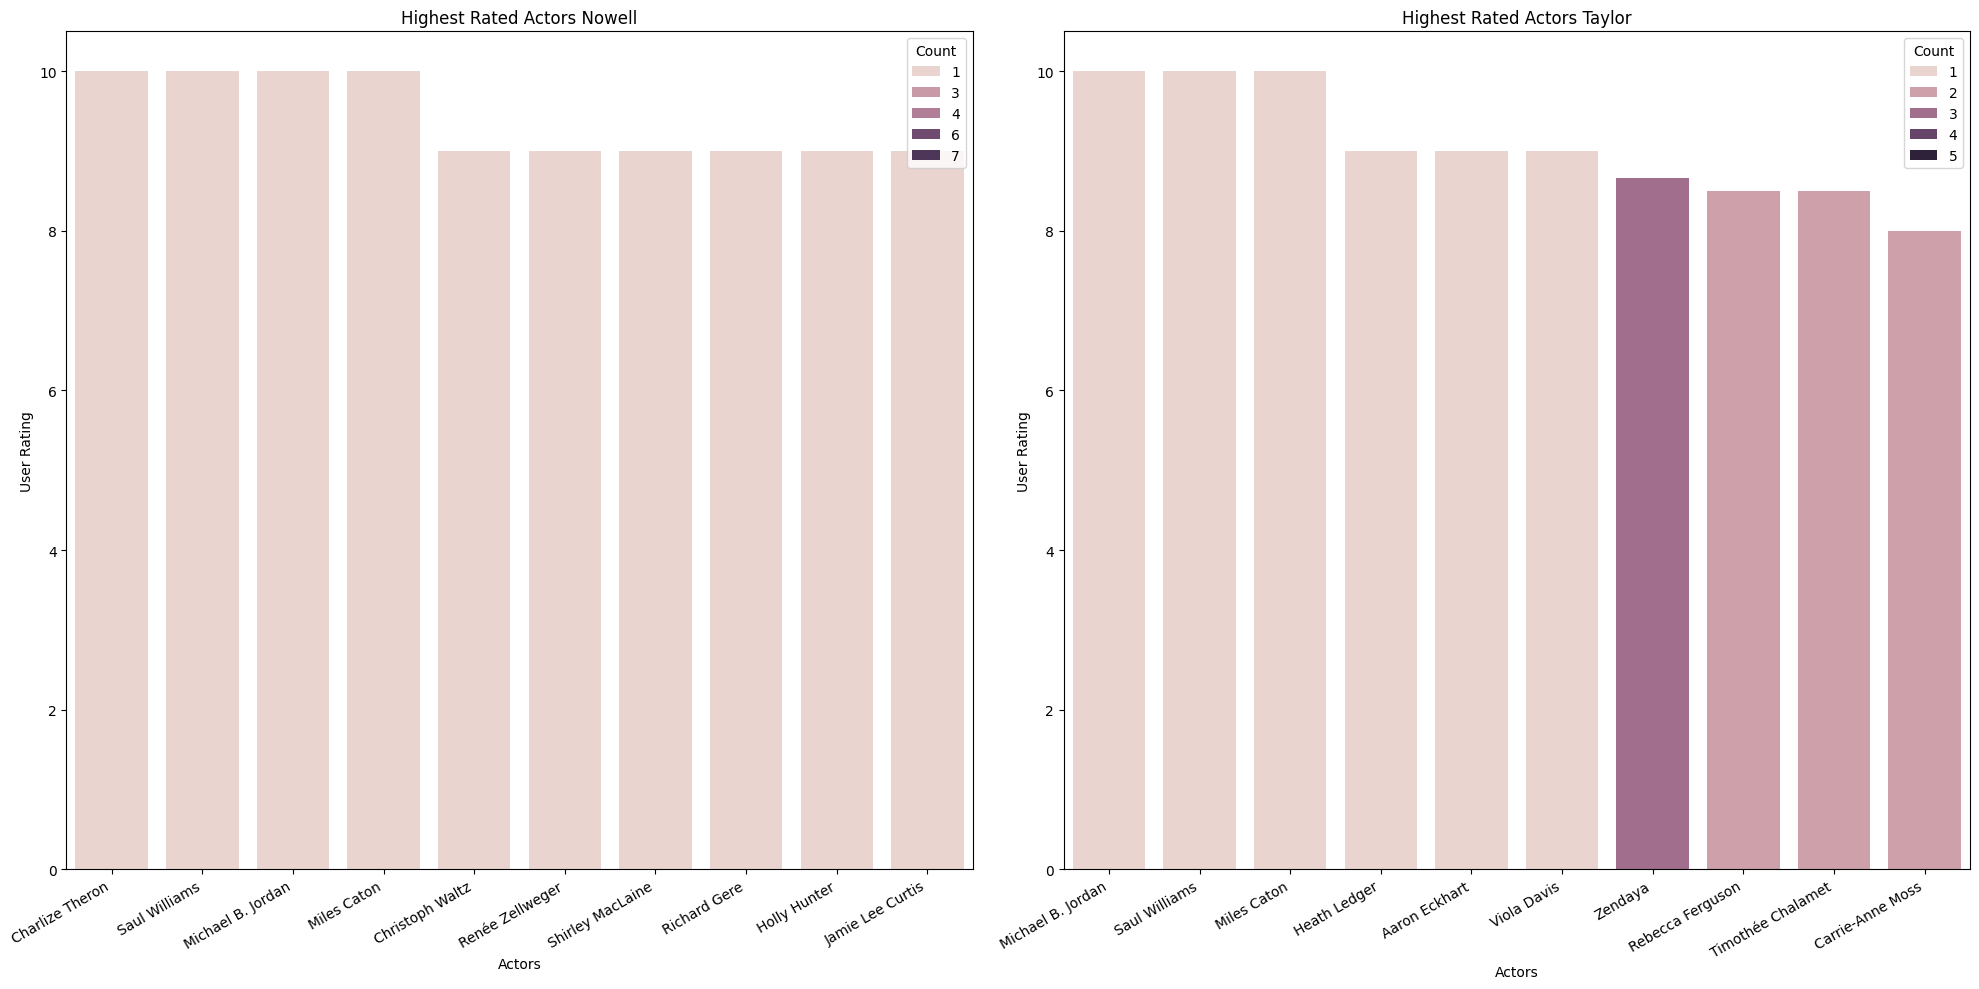

In [15]:
fig, (ax1, ax2) = plt.subplots(1,2 ,figsize=(20, 10))
g=sns.barplot(data=actor_summary_1,
              x='Actors', y='User Rating',
              ax=ax1,
              hue='Count',
              order = actor_summary_1.sort_values(by='User Rating', ascending=False)['Actors'][:10])
f=sns.barplot(data=actor_summary_2,
              x='Actors', y='User Rating',
              ax=ax2,
              hue='Count',
              order = actor_summary_2.sort_values(by='User Rating', ascending=False)['Actors'][:10])
fig.autofmt_xdate()
ax1.set_title('Highest Rated Actors Nowell')
ax2.set_title('Highest Rated Actors Taylor')
plt.tight_layout()
plt.show()

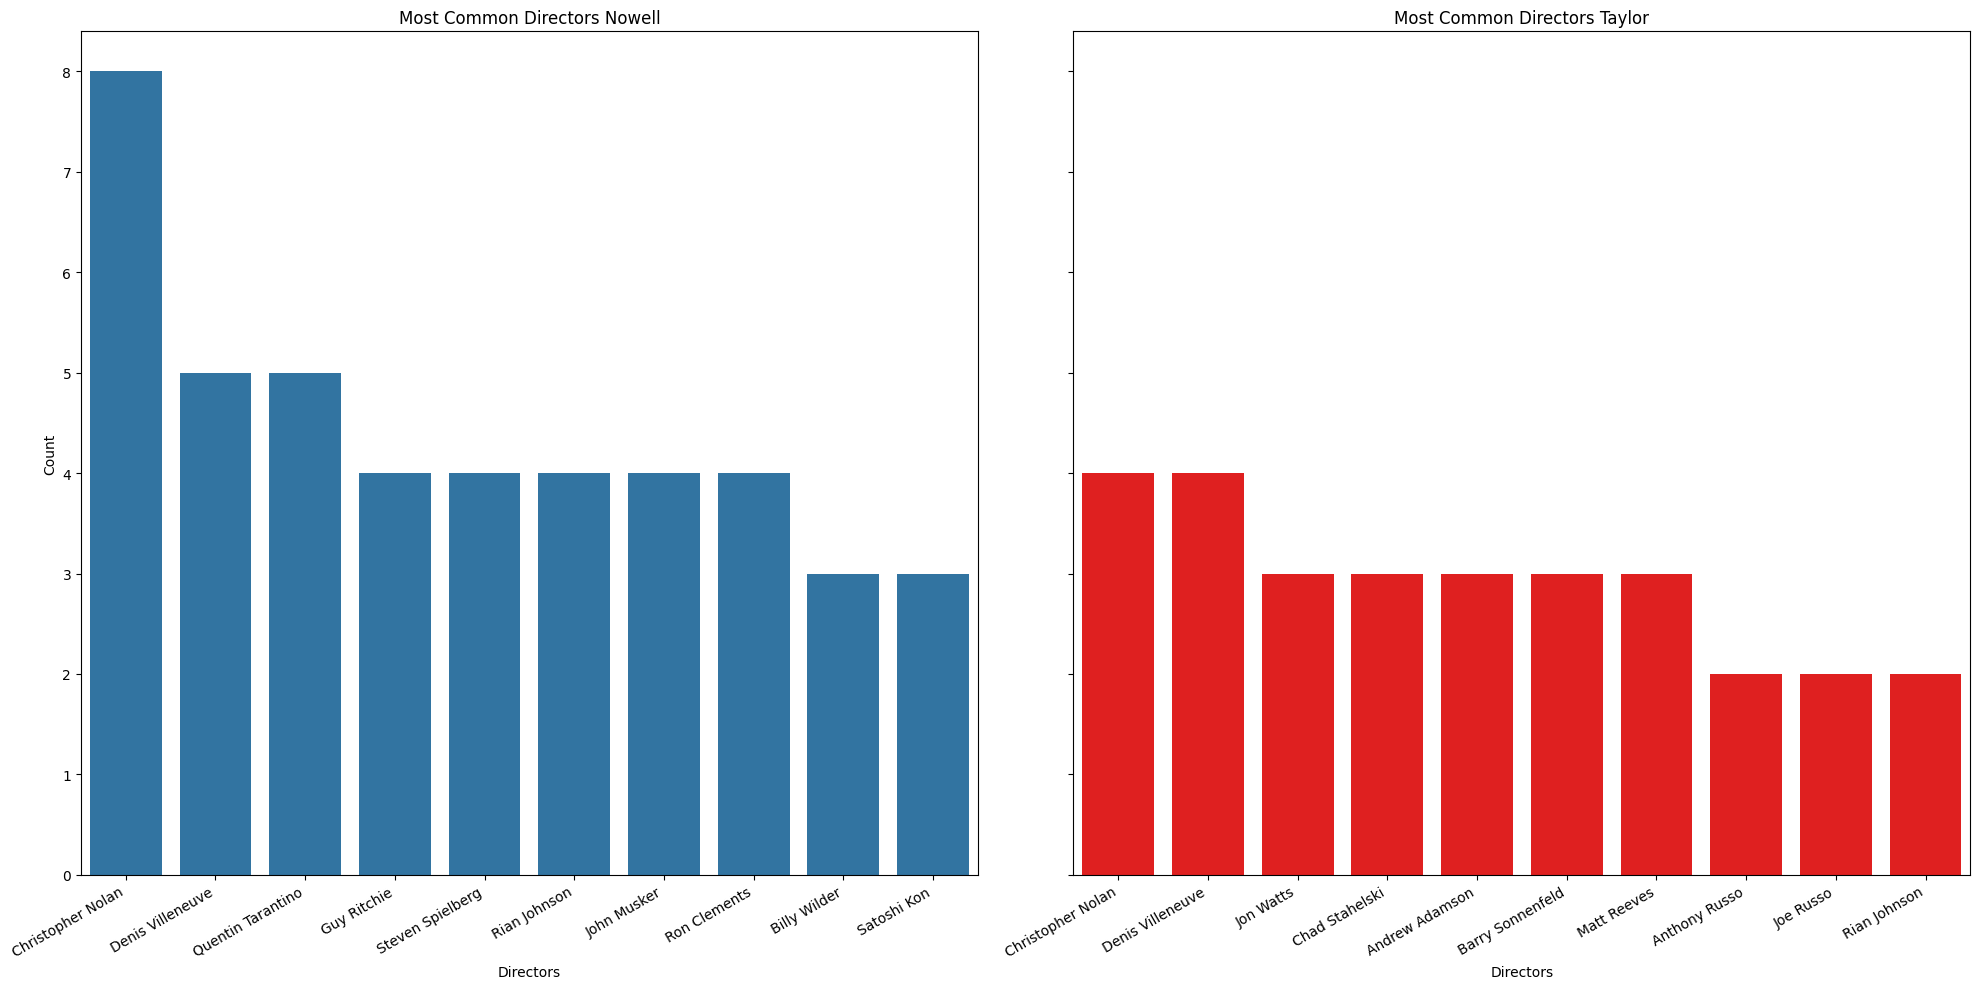

In [16]:
director_summary = df_directors.groupby(['Directors','Viewer']).agg({
    'User Rating': 'mean',
    'IMDb Rating': 'mean',
    'Directors': 'count'
}).rename(columns={'Directors': 'Count'}).sort_values(by=['Count', 'User Rating'], ascending=False)

director_summary.reset_index(inplace=True)

director_summary_1 = director_summary.loc[director_summary['Viewer']=='nowell']
director_summary_2 = director_summary.loc[director_summary['Viewer']=='taylor']

# Plots
fig, (ax1, ax2) = plt.subplots(1,2 ,figsize=(20, 10), sharey=True)
g=sns.barplot(data=director_summary_1,
              x='Directors', y='Count',
              ax=ax1,
              order = director_summary_1.sort_values(by='Count', ascending=False)['Directors'][:10])
f=sns.barplot(data=director_summary_2,
              x='Directors', y='Count',
              color = 'red', ax=ax2,
              order = director_summary_2.sort_values(by='Count', ascending=False)['Directors'][:10])
fig.autofmt_xdate()
ax1.set_title('Most Common Directors Nowell')
ax2.set_title('Most Common Directors Taylor')
plt.tight_layout()
plt.show()

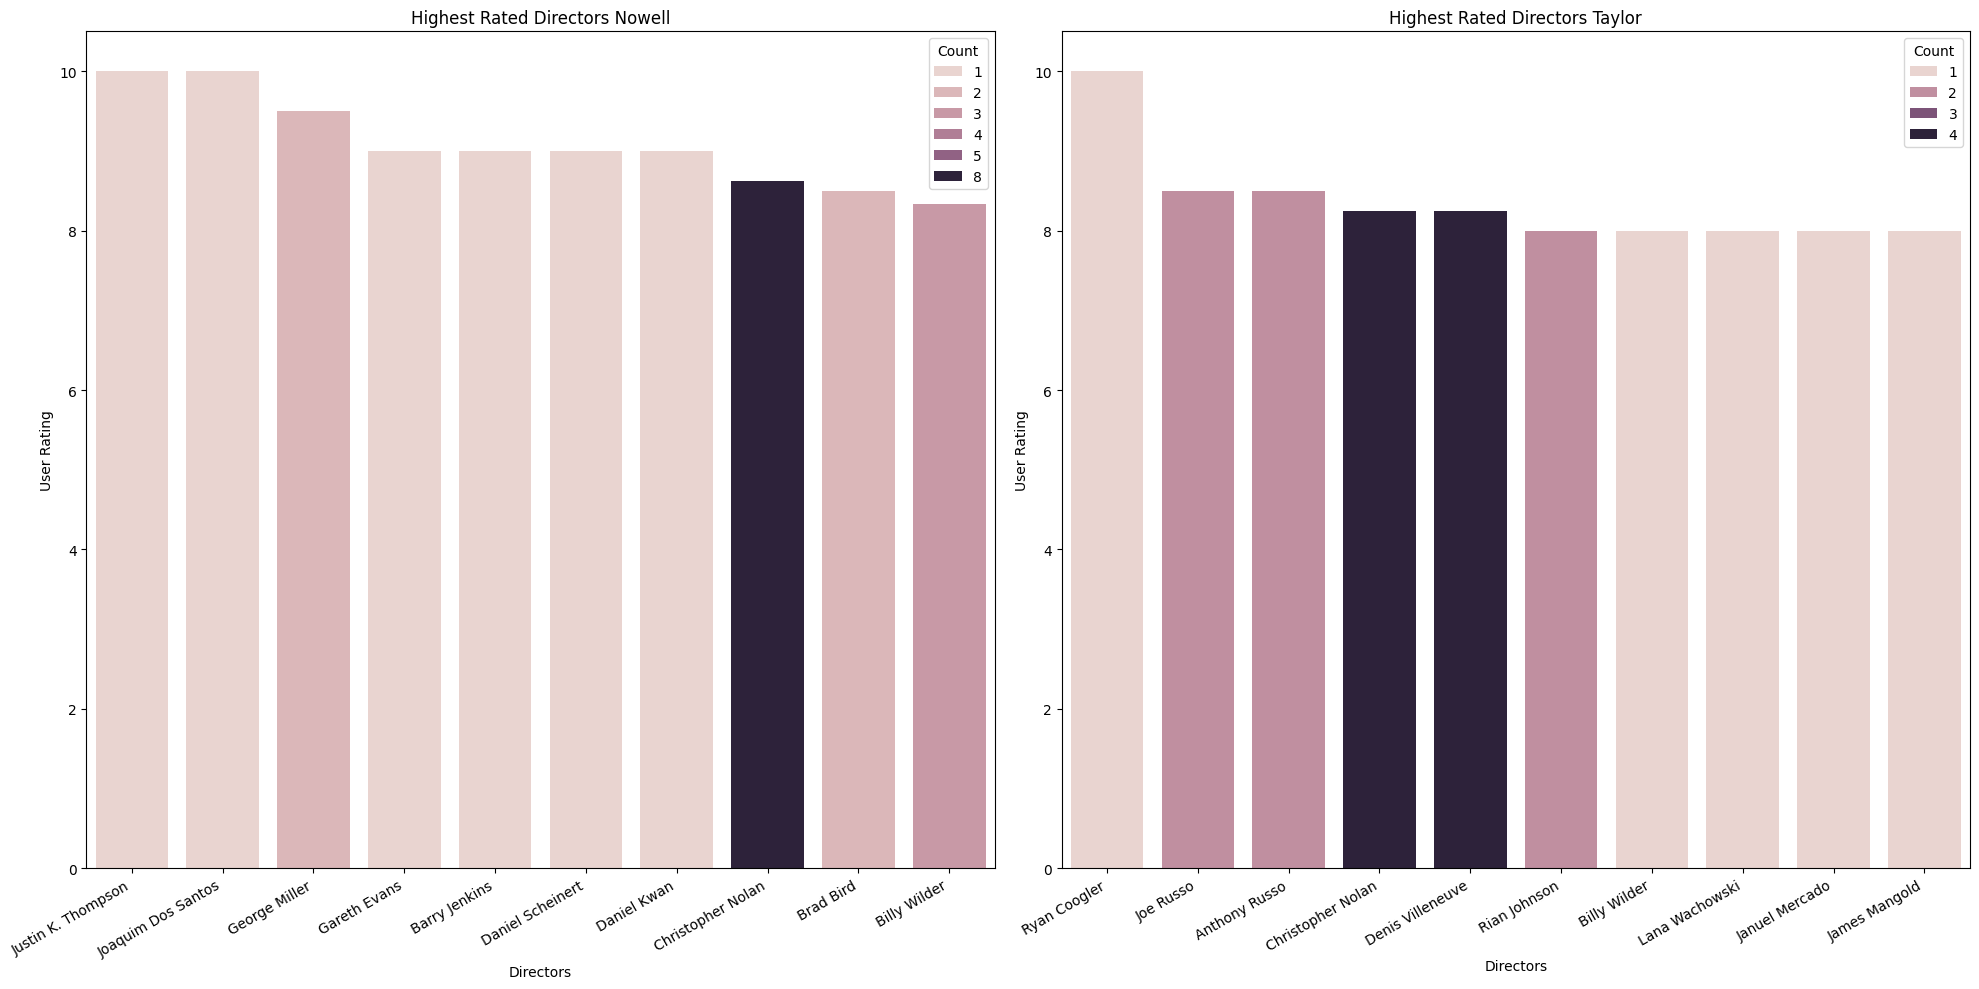

In [17]:
fig, (ax1, ax2) = plt.subplots(1,2 ,figsize=(20, 10))
g=sns.barplot(data=director_summary_1,
              x='Directors', y='User Rating',
              ax=ax1,
              hue='Count',
              order = director_summary_1.sort_values(by='User Rating', ascending=False)['Directors'][:10])
f=sns.barplot(data=director_summary_2,
              x='Directors', y='User Rating',
              ax=ax2,
              hue='Count',
              order = director_summary_2.sort_values(by='User Rating', ascending=False)['Directors'][:10])
fig.autofmt_xdate()
ax1.set_title('Highest Rated Directors Nowell')
ax2.set_title('Highest Rated Directors Taylor')
plt.tight_layout()
plt.show()

#### By Year

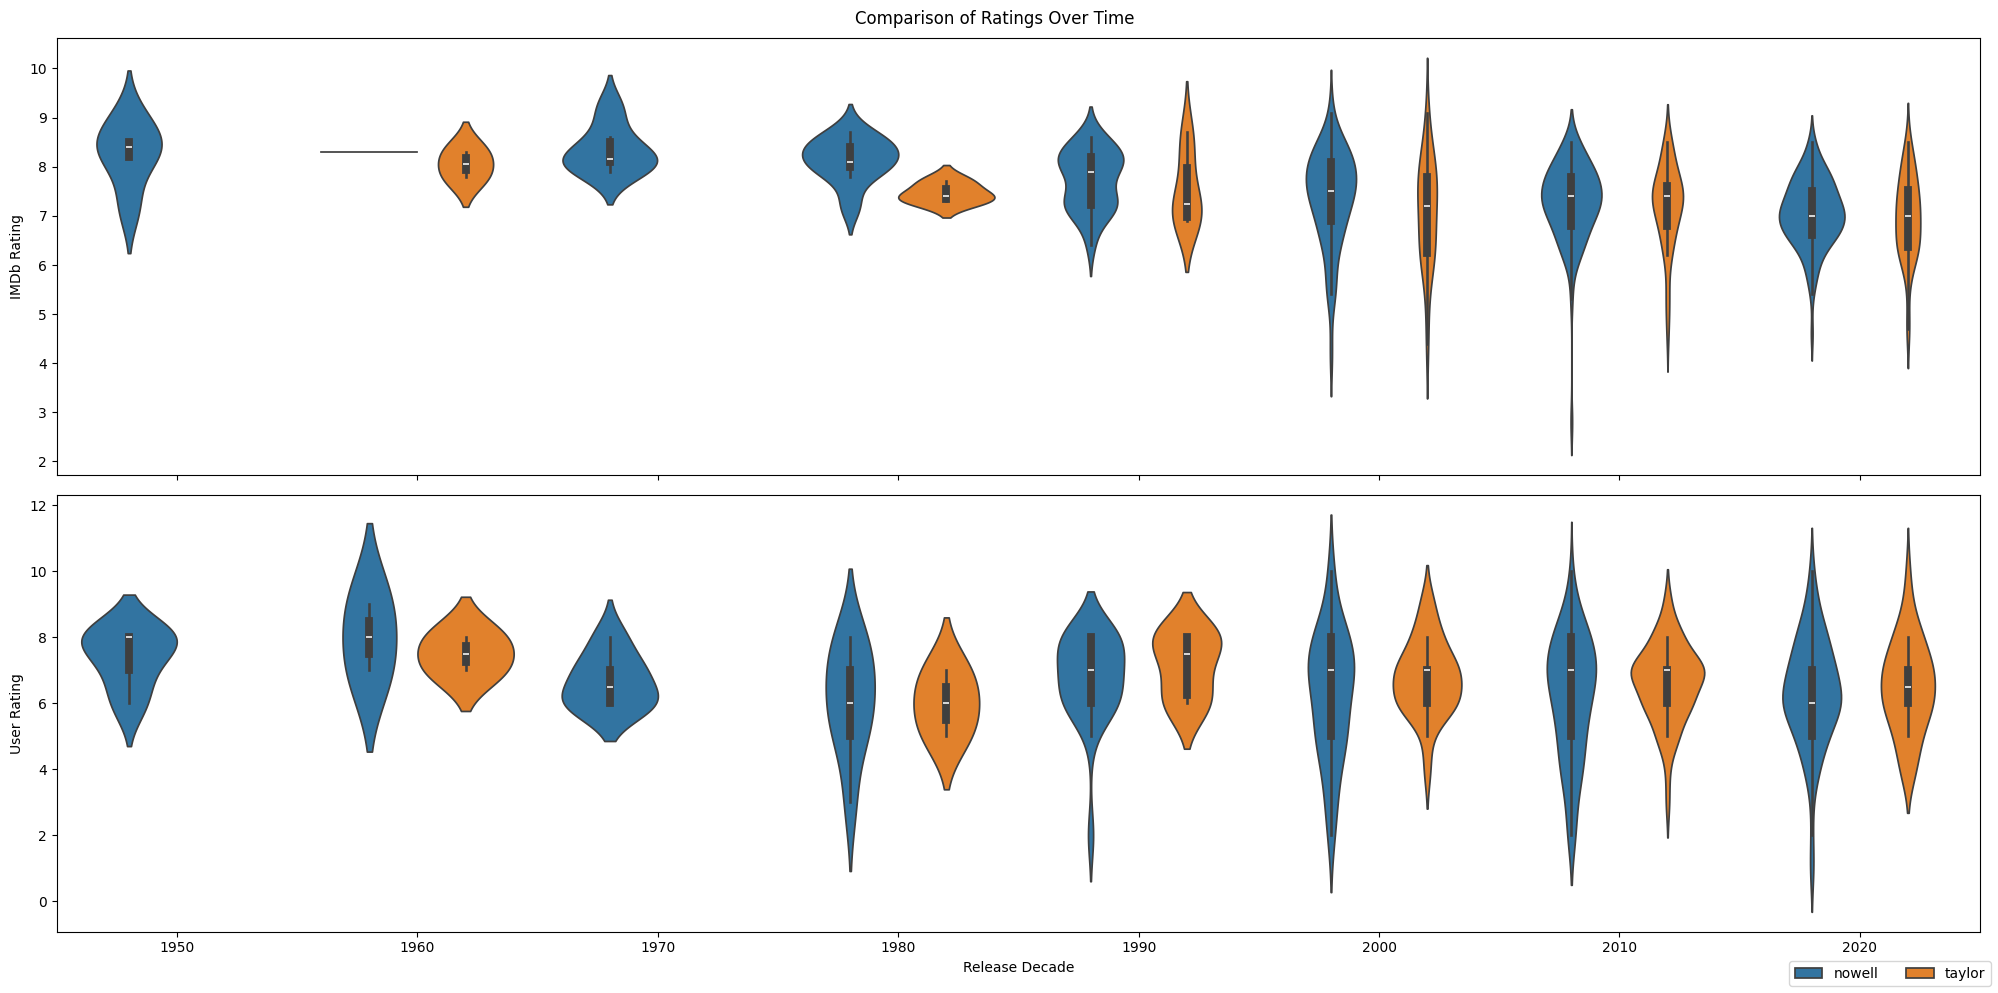

In [18]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(20, 10), sharex=True)

sns.violinplot(x='Release Decade', y='IMDb Rating', data=df, hue='Viewer', ax=axes[0])
sns.violinplot(x='Release Decade', y='User Rating', data=df, hue='Viewer', ax=axes[1], legend=False)
axes[0].legend_.remove()

fig.suptitle("Comparison of Ratings Over Time")
fig.legend(loc='lower right', ncols=2)
plt.tight_layout()

In [19]:
px.box(data_frame=df, y='IMDb Rating Rounded', x='Year Rated',
title = 'Rounded IMDb Ratings over time',
facet_col = 'Viewer',
hover_data={
        'Title': True,
        'User Rating': ':.2f',
        'IMDb Rating': ':.2f',
    } )

In [20]:
## Break down habits year by year
df['Year Rated'].value_counts()
display(df.groupby(['Year Rated','Viewer'])[['User Rating', 'IMDb Rating']].describe())

year_sum_1 = df[nowell].groupby('Year Rated').agg({
    'User Rating': 'mean',
    'IMDb Rating': 'mean',
    'Year Rated': 'count'
}).rename(columns={'Year Rated': 'Count'}
          ).sort_values(by=['Year Rated', 'User Rating'], ascending=False
                                                       )

display(year_sum_1.head(10))
correlation = year_sum_1['User Rating'].corr(year_sum_1['IMDb Rating'])
print(f"Correlation between Nowell's rating and IMDb rating: {correlation:.2f}")

User Rating                                                  \
                        count      mean       std  min   25%  50%   75%   max   
Year Rated Viewer                                                               
2020       nowell         9.0  5.333333  1.414214  4.0  4.00  5.0  6.00   8.0   
2021       nowell        54.0  5.500000  1.476227  2.0  5.00  6.0  7.00   8.0   
           taylor        42.0  6.690476  1.439649  3.0  6.00  7.0  8.00   9.0   
2022       nowell        18.0  5.722222  1.319784  3.0  5.00  6.0  6.75   8.0   
           taylor        32.0  6.187500  1.060660  4.0  6.00  6.0  7.00   8.0   
2023       nowell        20.0  6.050000  1.356272  2.0  5.00  6.0  7.00   8.0   
           taylor        15.0  7.066667  0.703732  6.0  7.00  7.0  7.50   8.0   
2024       nowell       157.0  6.757962  1.795298  1.0  6.00  7.0  8.00  10.0   
           taylor        30.0  6.666667  1.028334  4.0  6.00  7.0  7.00   8.0   
2025       nowell        32.0  6.468750  1.502350  3.0  6.00  7.0  7.00  10.0   
           taylor        14.0  6.928571  1.591530  4.0  6.25  7.0  7.75  10.0   

                  IMDb Rating                                               \
                        count      mean       std  min    25%   50%    75%   
Year Rated Viewer                                                            
2020       nowell         9.0  7.533333  0.781025  6.3  6.900  8.00  8.100   
2021       nowell        54.0  7.020370  0.821499  4.2  6.625  7.10  7.500   
           taylor        42.0  7.119048  1.043736  4.6  6.300  7.20  8.075   
2022       nowell        18.0  7.055556  0.536023  6.3  6.600  6.95  7.600   
           taylor        32.0  6.809375  0.861117  4.4  6.375  6.90  7.300   
2023       nowell        20.0  7.055000  0.760523  5.7  6.575  7.20  7.600   
           taylor        15.0  7.426667  0.411386  6.3  7.300  7.50  7.650   
2024       nowell       157.0  7.466242  0.883942  2.8  6.900  7.50  8.100   
           taylor        30.0  7.230000  0.920326  4.7  6.825  7.40  7.875   
2025       nowell        32.0  7.431250  0.495423  6.5  7.150  7.40  7.600   
           taylor        14.0  7.300000  0.593555  5.9  7.050  7.40  7.475   

                        
                   max  
Year Rated Viewer       
2020       nowell  8.2  
2021       nowell  8.2  
           taylor  9.1  
2022       nowell  7.9  
           taylor  8.3  
2023       nowell  8.3  
           taylor  8.0  
2024       nowell  9.2  
           taylor  8.4  
2025       nowell  8.5  
           taylor  8.5

,User Rating,IMDb Rating,Count
Year Rated,,,
2025,6.468750,7.431250,32
2024,6.757962,7.466242,157
2023,6.050000,7.055000,20
2022,5.722222,7.055556,18
2021,5.500000,7.020370,54
2020,5.333333,7.533333,9


Correlation between Nowell's rating and IMDb rating: 0.33


I'm seemingly getting more positive as time passes.

In [21]:
year_sum_2 = df[taylor].groupby('Year Rated').agg({
    'User Rating': 'mean',
    'IMDb Rating': 'mean',
    'Year Rated': 'count'
}).rename(columns={'Year Rated': 'Count'}).sort_values(by=['Year Rated', 'User Rating'], ascending=False)

display(year_sum_2.head(10))
correlation = year_sum_2['User Rating'].corr(year_sum_2['IMDb Rating'])
print(f"Correlation between Taylor's rating and IMDb rating: {correlation:.2f}")

,User Rating,IMDb Rating,Count
Year Rated,,,
2025,6.928571,7.300000,14
2024,6.666667,7.230000,30
2023,7.066667,7.426667,15
2022,6.187500,6.809375,32
2021,6.690476,7.119048,42


Correlation between Taylor's rating and IMDb rating: 0.98


Taylor seems quite consistent with his ratings

When did we start tracking?

In [22]:
min_date_1 = df[nowell]['Date Rated'].min()
min_date_2 = df[taylor]['Date Rated'].min()

print(f"Nowell started tracking on {min_date_1.date()} by watching {df[nowell].loc[df[nowell]['Date Rated'] == min_date_1, 'Title'].iloc[0]}")
print(f"Taylor started tracking on {min_date_2.date()} by watching {df[taylor].loc[df[taylor]['Date Rated'] == min_date_2, 'Title'].iloc[0]}")

Nowell started tracking on 2020-12-16 by watching Howl's Moving Castle
Taylor started tracking on 2021-04-04 by watching Django Unchained


##### Time Series

c:\Users\nowel\python_code\Movie-Analysis---Python-1\.venv\Lib\site-packages\seaborn\categorical.py:2761: UserWarning:

catplot is a figure-level function and does not accept target axes. You may wish to try stripplot



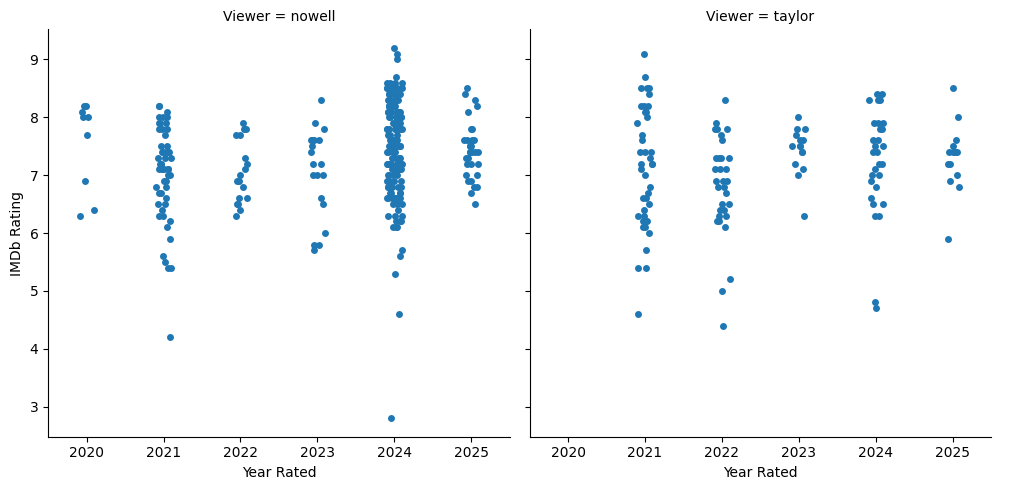

In [23]:
sns.catplot(
    data=df, x='Year Rated', y='IMDb Rating',
    col='Viewer', kind='strip',
    sharey=True, ax=ax1)
fig.suptitle('IMDb Rating Over Time')
fig.supxlabel('Year Rated')
plt.tight_layout()
plt.show()

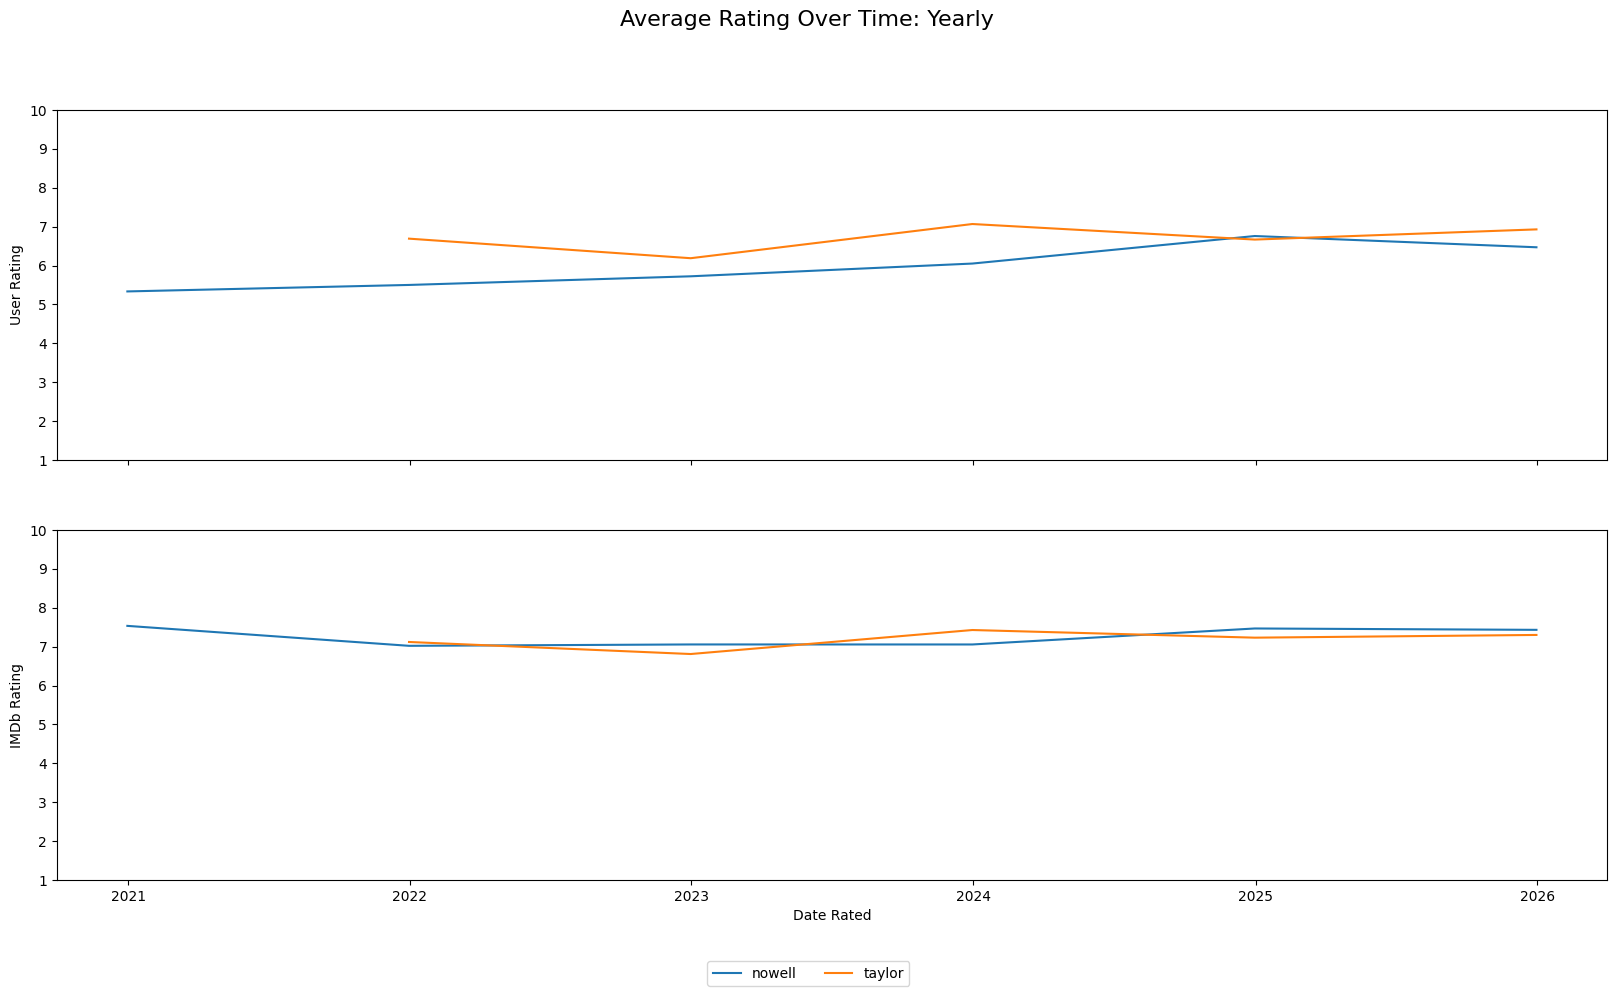

In [24]:
yearly  = df.groupby(['Viewer', pd.Grouper(key='Date Rated', freq='YE')]
                     )[['User Rating', 'IMDb Rating']].mean().reset_index()

fig, (ax1, ax2)=plt.subplots(2,1, figsize=(20, 10), sharex=True)
g=sns.lineplot(yearly,x='Date Rated', y='User Rating', hue='Viewer', ax=ax1, legend=False)
f=sns.lineplot(yearly,x='Date Rated', y='IMDb Rating', hue='Viewer', ax=ax2).legend_.remove()
ax1.set_ylim(1,10)
ax2.set_ylim(ax1.get_ylim())
fig.suptitle('Average Rating Over Time: Yearly', fontsize=16)
fig.legend(loc='lower center', ncols=2)
plt.show()

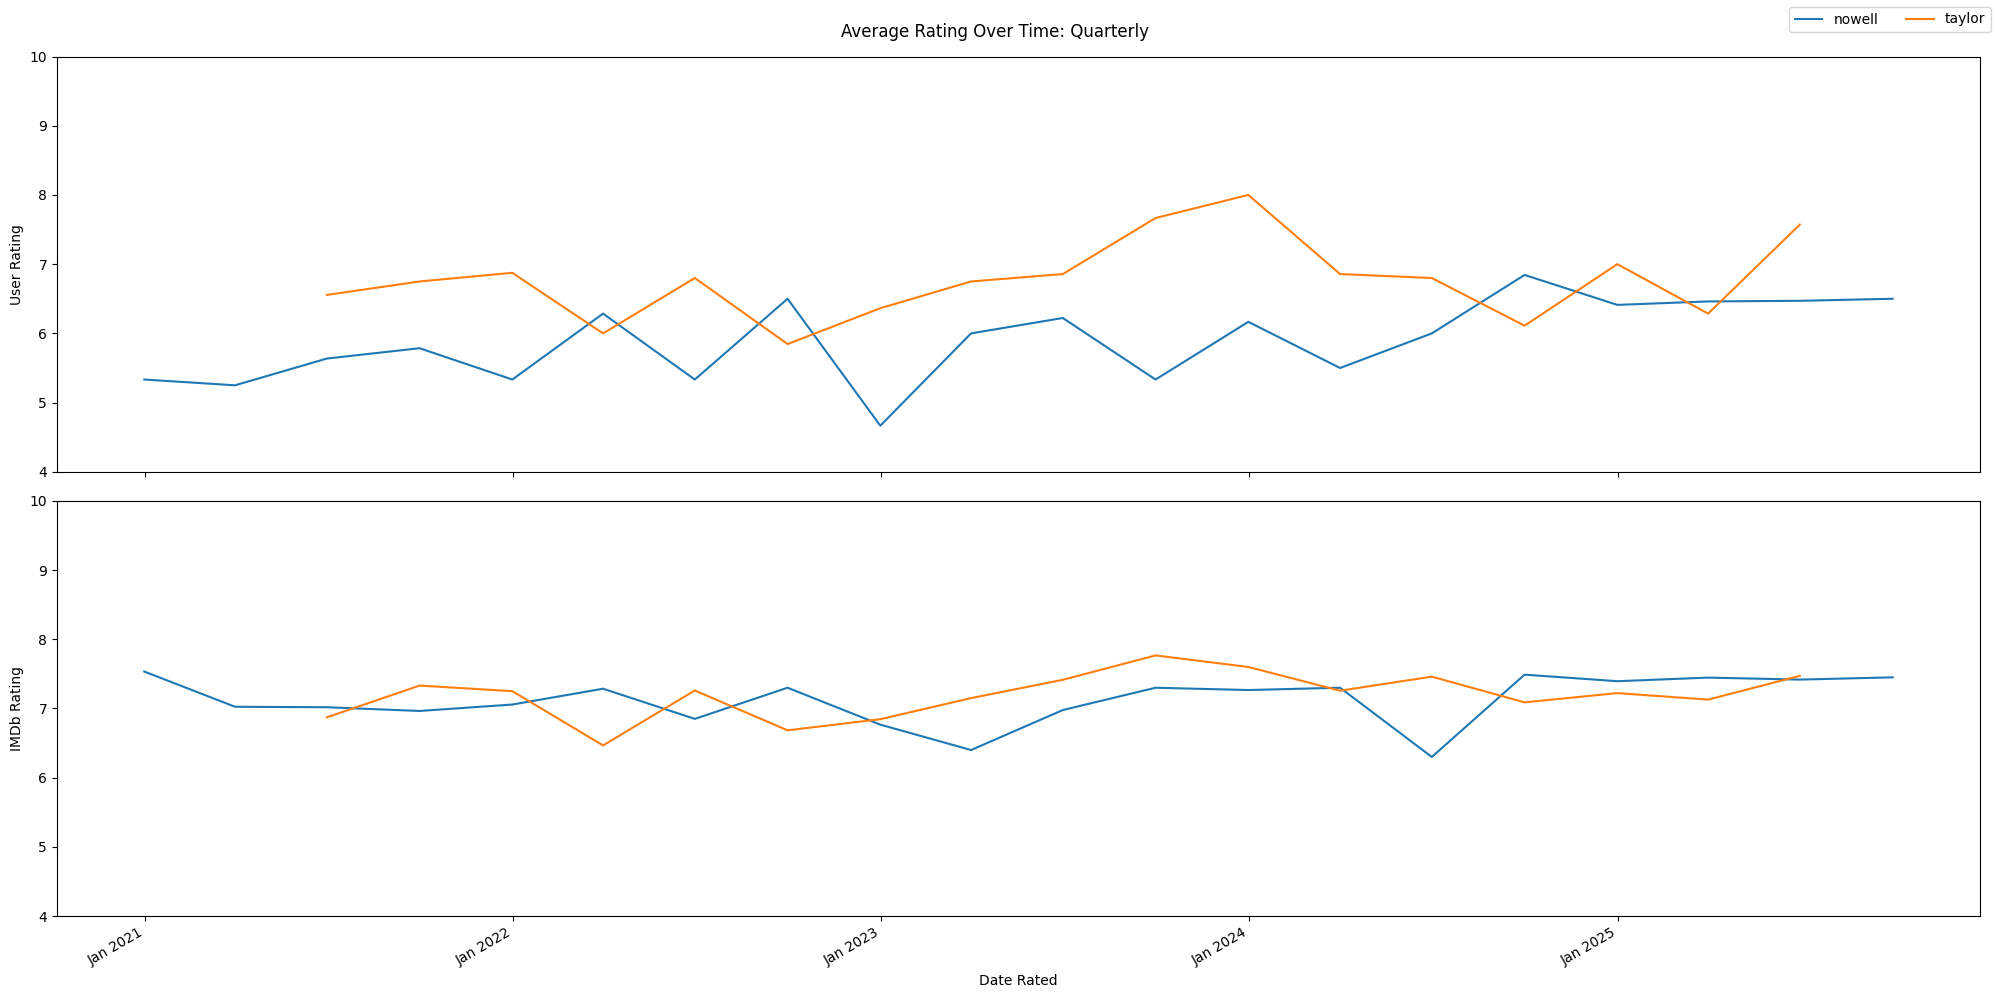

In [25]:
quarterly = (
    df.groupby(['Viewer',pd.Grouper(key='Date Rated', freq='QE')])
    [['User Rating', 'IMDb Rating']].mean()
    .reset_index()
)

fig, (ax1, ax2)=plt.subplots(2,1, figsize=(20, 10), sharex=True)
g=sns.lineplot(quarterly,x='Date Rated', y='User Rating',
               hue='Viewer', ax=ax1,
               legend=False)
f=sns.lineplot(quarterly,x='Date Rated', y='IMDb Rating',
               hue='Viewer', ax=ax2,
               )
mpl_dates.MonthLocator(bymonth=[1,4,7,10])
ax2.xaxis.set_major_formatter(mpl_dates.DateFormatter('%b %Y'))
ax2.legend_.remove()
ax1.set_ylim(4,10)
ax2.set_ylim(ax1.get_ylim())
fig.autofmt_xdate()
fig.suptitle('Average Rating Over Time: Quarterly')
fig.legend(ncols=2)
plt.tight_layout()
plt.show()

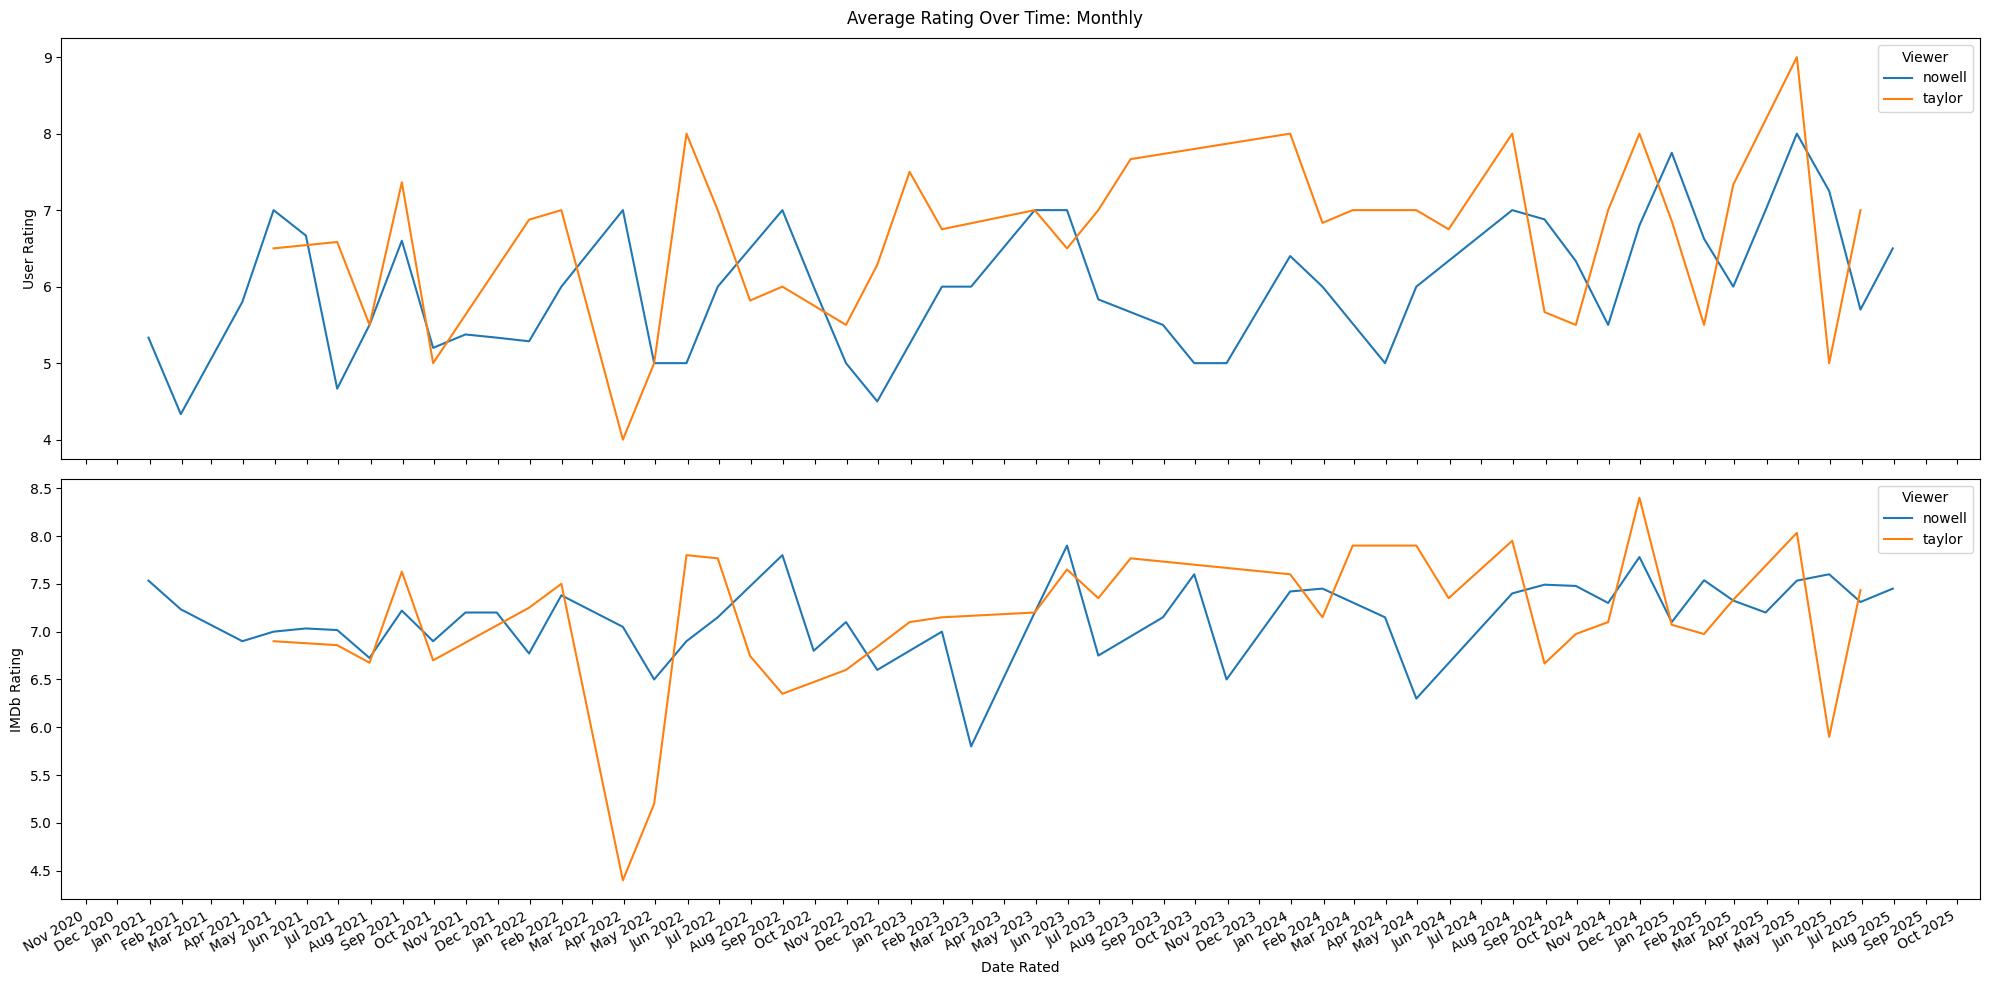

In [26]:
monthly = (
    df.groupby(['Viewer', pd.Grouper(key='Date Rated', freq='ME')])
      [['User Rating', 'IMDb Rating']].mean()
      .reset_index()
)

fig, (ax1, ax2)=plt.subplots(2,1, figsize=(20, 10), sharex=True)
fig.suptitle('Average Rating Over Time: Monthly')
g=sns.lineplot(monthly,x='Date Rated', y='User Rating', hue='Viewer', ax=ax1)
f=sns.lineplot(monthly,x='Date Rated', y='IMDb Rating', hue='Viewer', ax=ax2)
# Set x-axis to monthly ticks
ax2.xaxis.set_major_locator(mpl_dates.MonthLocator())
ax2.xaxis.set_major_formatter(mpl_dates.DateFormatter('%b %Y'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

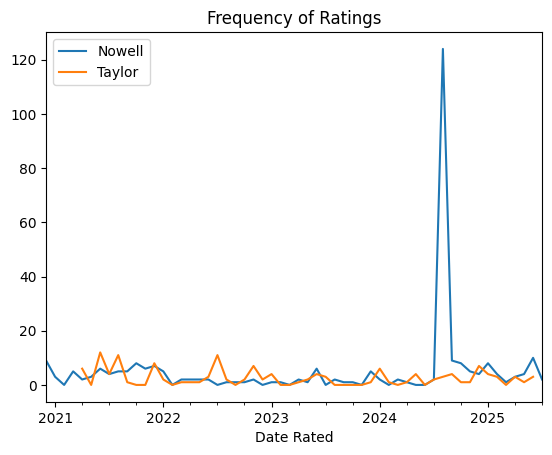

In [27]:
df[nowell].set_index('Date Rated').resample('ME')['User Rating'].count().plot(
    title='Frequency of Ratings',
    label='Nowell')
df[taylor].set_index('Date Rated').resample('ME')['User Rating'].count().plot(
    title='Frequency of Ratings',
    label='Taylor')
plt.legend()

<Axes: title={'center': 'Frequency of Ratings'}, xlabel='Date Rated'>

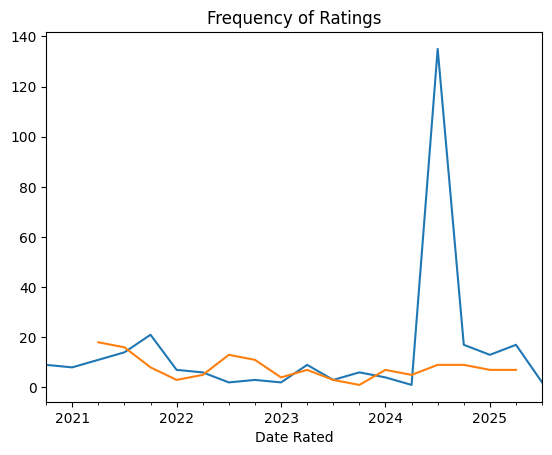

In [28]:
df[nowell].set_index('Date Rated').resample('QE')['User Rating'].count().plot(title='Frequency of Ratings')
df[taylor].set_index('Date Rated').resample('QE')['User Rating'].count().plot(title='Frequency of Ratings')

In [29]:
# # Plot average rating by when I rated
# df.groupby('Month Rated')['User Rating'].mean().plot(
#     title='Average Rating by Month Watched',
#     ylabel='My Rating',
#     xlabel='Month (1 = Jan)'
# )

# # Plot average rating by movie's release month
# df.groupby('Release Month')['User Rating'].mean().plot(
#     title='Average Rating by Release Month',
#     ylabel='My Rating',
#     xlabel='Month (1 = Jan)',
#     style='--'
# )

monthly_rating = df.groupby(['Viewer','Release Month']).agg({
    'User Rating': 'mean',
    'IMDb Rating': 'mean',
    'Title': 'count'
}).rename(columns={'Title': 'Count'}).sort_values(by=['Release Month', 'User Rating'], ascending=False)

# sns.lineplot(x=monthly_rating.index, y=monthly_rating.values)
# plt.title('Average Rating by Month')
# plt.xlabel('Date Rated')
# plt.ylabel('Average Rating')
# plt.show()

monthly_rating.reset_index()


# f=sns.relplot(data=monthly_rating, x='Release Month', y='User Rating', hue='Viewer', kind='line')
# g=sns.relplot(data=monthly_rating, x='Release Month', y='IMDb Rating', hue='Viewer', kind='line')
# .title('Average Rating by Release Month')
plt.show()

Big variation throughout the seasons.

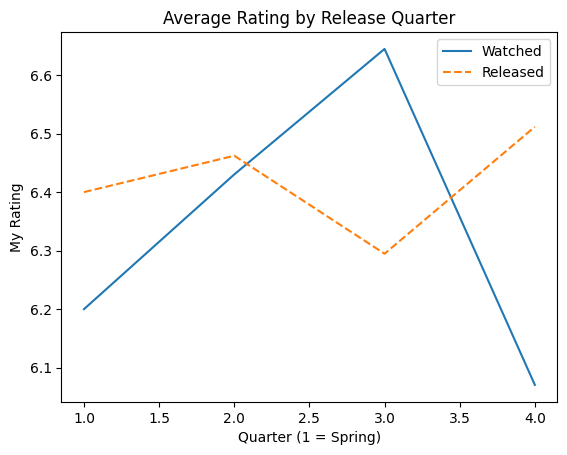

In [30]:
# Plot average rating by *when I rated*
df.groupby('Season Rated')['User Rating'].mean().plot(
    title='Average Rating by Quarter Watched',
    ylabel='My Rating',
    xlabel='Quarter (1 = Spring)'
)

# Plot average rating by *movie's release month*
df.groupby('Release Season')['User Rating'].mean().plot(
    title='Average Rating by Release Quarter',
    ylabel='My Rating',
    xlabel='Quarter (1 = Spring)',
    style='--'
)
plt.legend(['Watched', 'Released'])

Massive gulf in rating over the summer for release date. Suggests I don't love blockbusters.

In [31]:
display(df['Release Season'].value_counts())
display(df['Season Rated'].value_counts())

Release Season
4    129
2    119
3     95
1     80
Name: count, dtype: int64

Season Rated
3    197
2     86
4     85
1     55
Name: count, dtype: int64

### How mainstream are our tastes?

#### Hot takes

In [32]:
## Creating filters
favs=(df['User Rating']>df['IMDb Rating'])
goodmv = (df['IMDb Rating']>7)
hottake = abs(df['User Rating'] - df['IMDb Rating']) >=1
tens = df['User Rating']==10

movie_details = df.columns[:8]

In [33]:
favourite_movies_nowell = df[favs&hottake&nowell][movie_details].sort_values(
    by=['User Rating','Date Rated'], ascending= False)
print("Nowell positive hot takes",favourite_movies_nowell.shape)
favourite_movies_nowell

Nowell positive hot takes (20, 8)


,Title,IMDb Rating,User Rating,Viewer,Release Date,Date Rated,Box Office Millions,Num Votes Thousands
21,Sinners,7.6,10,nowell,2025-04-18,2025-04-18 21:35:56+00:00,278.578513,288.689
111,Spider-Man: Across the Spider-Verse,8.5,10,nowell,2023-06-02,2024-08-29 20:31:27+00:00,381.593754,477.183
201,The Prestige,8.5,10,nowell,2006-10-20,2024-08-09 04:48:51+00:00,53.089891,1538.383
208,Mad Max: Fury Road,8.1,10,nowell,2015-05-15,2024-08-09 04:46:27+00:00,154.280290,1183.848
104,Killers of the Flower Moon,7.5,9,nowell,2023-10-20,2024-08-29 20:32:45+00:00,68.035488,291.667
108,Moonlight,7.4,9,nowell,2016-11-18,2024-08-29 20:32:10+00:00,27.854932,345.000
143,The Raid: Redemption,7.6,9,nowell,2012-04-13,2024-08-29 20:10:31+00:00,4.105187,225.910
147,Tenet,7.3,9,nowell,2020-09-03,2024-08-29 20:09:11+00:00,58.504105,641.768
156,The Incredibles,8.0,9,nowell,2004-11-05,2024-08-26 19:47:37+00:00,261.441092,875.373
159,Alien: Romulus,7.1,9,nowell,2024-08-16,2024-08-22 00:05:30+00:00,105.313091,269.109


In [34]:
favourite_movies_taylor = df[favs&hottake&taylor][movie_details].sort_values(by=['User Rating','Date Rated'], ascending= False)
print("Taylor positive hot takes",favourite_movies_taylor.shape)
favourite_movies_taylor

Taylor positive hot takes (2, 8)


,Title,IMDb Rating,User Rating,Viewer,Release Date,Date Rated,Box Office Millions,Num Votes Thousands
22,Sinners,7.6,10,taylor,2025-04-18,2025-04-18 22:20:16+00:00,278.578513,288.689
414,Shark Tale,6.0,7,taylor,2004-10-01,2021-06-08 00:00:00+00:00,160.861908,208.430


In [35]:
hottake_nowell = df[hottake&nowell][movie_details].sort_values(by=['User Rating','Date Rated'], ascending= False)
print("Nowell hot takes",hottake_nowell.shape)
hottake_nowell

Nowell hot takes (139, 8)


,Title,IMDb Rating,User Rating,Viewer,Release Date,Date Rated,Box Office Millions,Num Votes Thousands
21,Sinners,7.6,10,nowell,2025-04-18,2025-04-18 21:35:56+00:00,278.578513,288.689
111,Spider-Man: Across the Spider-Verse,8.5,10,nowell,2023-06-02,2024-08-29 20:31:27+00:00,381.593754,477.183
201,The Prestige,8.5,10,nowell,2006-10-20,2024-08-09 04:48:51+00:00,53.089891,1538.383
208,Mad Max: Fury Road,8.1,10,nowell,2015-05-15,2024-08-09 04:46:27+00:00,154.280290,1183.848
104,Killers of the Flower Moon,7.5,9,nowell,2023-10-20,2024-08-29 20:32:45+00:00,68.035488,291.667
...,...,...,...,...,...,...,...,...
197,12 Rounds,5.6,2,nowell,2009-03-27,2024-08-09 05:33:43+00:00,12.234694,30.927
242,The Babysitter: Killer Queen,5.8,2,nowell,2020-09-10,2023-06-11 00:00:00+00:00,NaN,55.450
297,Olympus Has Fallen,6.5,2,nowell,2013-03-22,2021-09-04 00:00:00+00:00,98.925640,302.488
92,The Strangers: Chapter 1,4.6,1,nowell,2024-05-17,2024-08-29 20:38:44+00:00,35.202562,24.124


In [36]:
hottake_taylor = df[hottake&taylor][movie_details].sort_values(by=['User Rating','Date Rated'], ascending= False)
print("Taylor positive hot takes",hottake_taylor.shape)
hottake_taylor

Taylor positive hot takes (28, 8)


,Title,IMDb Rating,User Rating,Viewer,Release Date,Date Rated,Box Office Millions,Num Votes Thousands
22,Sinners,7.6,10,taylor,2025-04-18,2025-04-18 22:20:16+00:00,278.578513,288.689
106,Oppenheimer,8.3,7,taylor,2023-07-21,2024-01-27 00:00:00+00:00,330.078895,945.602
405,The Imitation Game,8.0,7,taylor,2014-12-25,2021-08-07 00:00:00+00:00,91.125683,860.739
414,Shark Tale,6.0,7,taylor,2004-10-01,2021-06-08 00:00:00+00:00,160.861908,208.430
352,Prometheus,7.0,6,taylor,2012-06-08,2024-09-29 18:16:35+00:00,126.477084,686.571
354,A Quiet Place,7.5,6,taylor,2018-04-06,2024-08-22 20:32:36+00:00,188.024361,637.961
229,Coraline,7.8,6,taylor,2009-02-06,2024-08-21 14:15:27+00:00,116.896576,289.299
358,War for the Planet of the Apes,7.4,6,taylor,2017-07-14,2024-05-17 00:00:00+00:00,146.880162,318.910
125,Prey,7.1,6,taylor,2022-08-05,2023-06-14 00:00:00+00:00,NaN,256.314
234,Moana,7.6,6,taylor,2016-11-23,2023-05-20 00:00:00+00:00,248.757044,425.722


In [37]:
# Using SD to find the outliers
df['Difference'] = df['User Rating'] - df['IMDb Rating']

mean_diff = df['Difference'].mean()
std_diff = df['Difference'].std()

threshold = 2 * std_diff
df['Hot_Take'] = df['Difference'].abs() > threshold

# Add labels
def label_hot_take(row):
    if row['Difference'] > threshold:
        return 'Overrated'
    elif row['Difference'] < -threshold:
        return 'Underrated'
    else:
        return 'Normal'

df['Hot_Take_Label'] = df.apply(label_hot_take, axis=1)

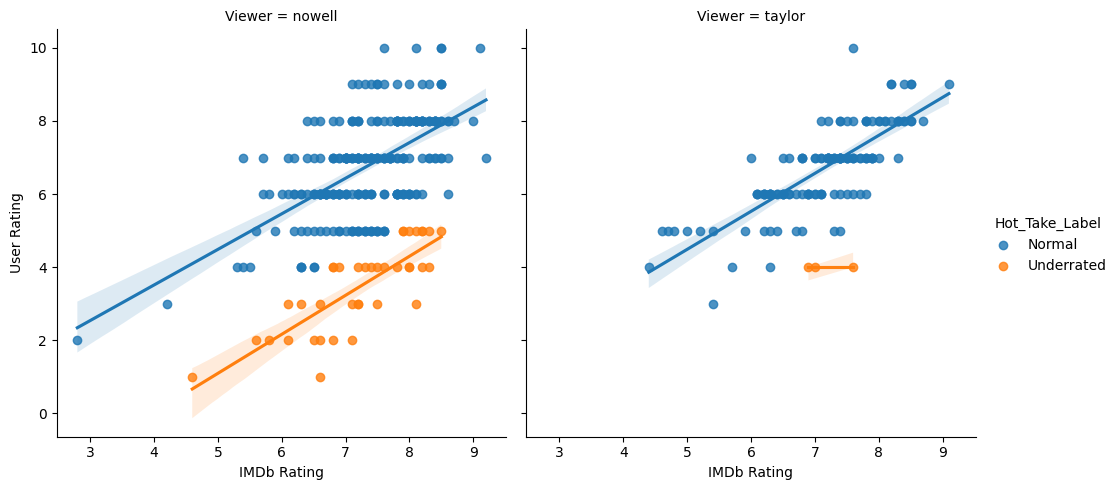

In [38]:
sns.lmplot(data=df, x='IMDb Rating', y='User Rating',
                hue='Hot_Take_Label',col='Viewer')
# plt.plot([0, 10], [0, 10], linestyle='--', color='gray')  # Line of fit
# fig.title('User Ratings vs IMDb Rating')
fig.legend(title='Hot Take Status')
plt.show()

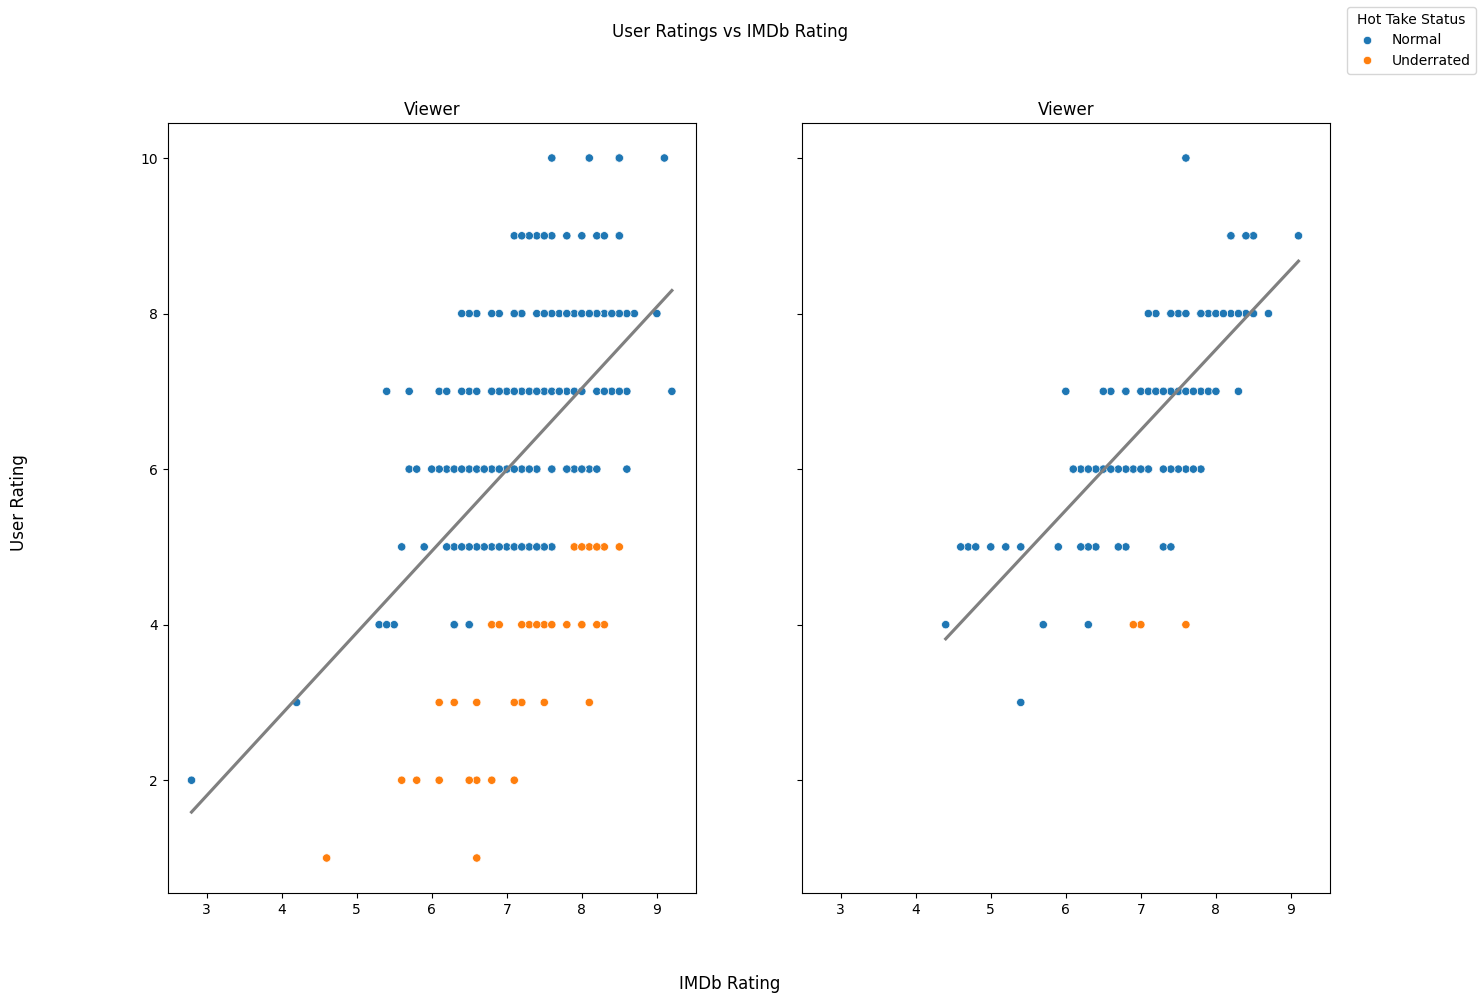

In [39]:
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,10), sharey=True, sharex=True)
# sns.scatterplot(data=df[nowell], x='IMDb Rating', y='User Rating',
#                 hue='Hot_Take_Label', ax=ax1)
# sns.scatterplot(data=df[taylor], x='IMDb Rating', y='User Rating',
#                 hue='Hot_Take_Label', legend=False,
#                 ax=ax2)
# fig.suptitle('User Ratings vs IMDb Rating')
# fig.supxlabel('IMDb Rating')
# fig.supylabel('User Rating')
# ax1.legend_.remove()
# ax1.set_xlabel(None)
# ax1.set_ylabel(None)
# ax2.set_xlabel(None)
# ax2.set_ylabel(None)
# fig.legend(title='Hot Take Status')
# plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 10), sharex=True, sharey=True)
axes = [ax1, ax2]
viewers = [nowell, taylor]

for ax, viewer in zip(axes, viewers):
    sns.scatterplot(data=df[viewer], x='IMDb Rating', y='User Rating',
                    hue='Hot_Take_Label', ax=ax)
    sns.regplot(data=df[viewer], x='IMDb Rating', y='User Rating',
                scatter=False, ax=ax, color='gray', marker="o", ci=None)
    ax.set_xlabel(None)
    ax.set_ylabel(None)
    ax.legend_.remove()
    ax.set_title(f'{viewer.name.capitalize()}')

fig.suptitle('User Ratings vs IMDb Rating')
fig.supxlabel('IMDb Rating')
fig.supylabel('User Rating')

fig.legend(*ax1.get_legend_handles_labels(), title='Hot Take Status')
plt.show()


#### Votes

In [40]:
df.groupby('Viewer')['Num Votes'].describe()

,count,mean,std,min,25%,50%,75%,max
Viewer,,,,,,,,
nowell,290.0,445984.093103,451130.552544,3545.0,121984.25,306583.5,599045.75,3074817.0
taylor,133.0,447545.578947,452821.402731,496.0,161086.00,318351.0,596881.00,3074817.0


In [41]:
# Most popular movies in the df
display(df[nowell][movie_details].sort_values(by = 'Num Votes Thousands',ascending=False).head(30))
display(df[taylor][movie_details].sort_values(by = 'Num Votes Thousands',ascending=False).head(30))

,Title,IMDb Rating,User Rating,Viewer,Release Date,Date Rated,Box Office Millions,Num Votes Thousands
203,The Dark Knight,9.1,10,nowell,2008-07-18,2024-08-09 04:48:41+00:00,534.987076,3074.817
47,The Godfather,9.2,7,nowell,1972-03-24,2024-11-01 19:39:44+00:00,136.381073,2160.424
36,The Dark Knight Rises,8.4,8,nowell,2012-07-20,2025-01-03 17:39:58+00:00,448.149584,1942.437
15,Django Unchained,8.5,9,nowell,2012-12-25,2025-05-19 19:33:35+00:00,162.805434,1825.738
163,Gladiator,8.5,7,nowell,2000-05-05,2024-08-10 07:52:49+00:00,187.705427,1795.475
146,Inglourious Basterds,8.4,8,nowell,2009-08-21,2024-08-29 20:09:36+00:00,120.540719,1712.358
220,Batman Begins,8.2,8,nowell,2005-06-15,2024-07-29 19:22:37+00:00,206.863479,1673.263
90,The Silence of the Lambs,8.6,8,nowell,1991-02-14,2024-08-29 20:39:01+00:00,130.742922,1667.162
77,Joker,8.3,4,nowell,2019-10-04,2024-08-30 06:56:47+00:00,335.477657,1637.986
5,Shutter Island,8.2,5,nowell,2010-02-19,2025-06-03 19:43:59+00:00,128.012934,1581.281


,Title,IMDb Rating,User Rating,Viewer,Release Date,Date Rated,Box Office Millions,Num Votes Thousands
204,The Dark Knight,9.1,9,taylor,2008-07-18,2021-08-02 00:00:00+00:00,534.987076,3074.817
406,The Matrix,8.7,8,taylor,1999-03-31,2021-08-02 00:00:00+00:00,172.076928,2187.692
16,Django Unchained,8.5,8,taylor,2012-12-25,2021-04-04 00:00:00+00:00,162.805434,1825.738
202,The Prestige,8.5,9,taylor,2006-10-20,2021-12-23 00:00:00+00:00,53.089891,1538.383
218,Memento,8.4,8,taylor,2001-05-25,2024-11-18 15:41:38+00:00,25.544867,1397.080
397,Avengers: Endgame,8.4,9,taylor,2019-04-26,2021-12-19 00:00:00+00:00,858.373000,1390.337
356,Avengers: Infinity War,8.4,8,taylor,2018-04-27,2024-07-11 13:45:20+00:00,678.815482,1321.746
216,The Truman Show,8.2,8,taylor,1998-06-05,2021-04-09 00:00:00+00:00,125.618201,1320.152
200,Parasite,8.5,8,taylor,2019-11-08,2021-08-02 00:00:00+00:00,53.847897,1100.523
411,"Monsters, Inc.",8.1,8,taylor,2001-11-02,2021-06-11 00:00:00+00:00,290.642256,1045.975


In [42]:
# Least popular movies in the df
display(df[nowell][movie_details].sort_values(by = 'Num Votes Thousands',ascending=True).head(30))
display(df[taylor][movie_details].sort_values(by = 'Num Votes Thousands',ascending=True).head(30))

,Title,IMDb Rating,User Rating,Viewer,Release Date,Date Rated,Box Office Millions,Num Votes Thousands
164,The Lorax,7.9,7,nowell,1972-02-14,2024-08-10 07:52:34+00:00,NaN,3.545
341,Dave Chappelle: 8:46,8.1,8,nowell,2020-06-12,2020-12-16 00:00:00+00:00,NaN,3.942
267,Hilda and the Mountain King,7.7,7,nowell,2021-12-30,2022-01-30 00:00:00+00:00,NaN,4.179
87,Konosuba!: God's Blessing on This Wonderful Wo...,7.8,8,nowell,2019-08-30,2024-08-30 06:55:24+00:00,1.134786,6.237
161,Ultraman: Rising,6.9,6,nowell,2024-06-14,2024-08-16 12:17:31+00:00,NaN,7.019
31,Humanist Vampire Seeking Consenting Suicidal P...,7.0,7,nowell,2024-02-15,2025-01-18 20:08:50+00:00,0.015092,8.736
333,Blue Story,6.3,4,nowell,2020-05-05,2020-12-22 00:00:00+00:00,NaN,8.971
248,Falcon Rising,5.8,6,nowell,2014-09-04,2023-02-27 00:00:00+00:00,0.011774,9.691
304,Steins;Gate: The Movie - Load Region of Déjà Vu,7.8,6,nowell,2013-04-20,2021-08-27 00:00:00+00:00,NaN,10.631
298,The Young Offenders,7.1,7,nowell,2016-09-16,2021-09-04 00:00:00+00:00,NaN,13.510


,Title,IMDb Rating,User Rating,Viewer,Release Date,Date Rated,Box Office Millions,Num Votes Thousands
420,The Weekend,4.6,5,taylor,2016-12-02,2021-04-05 00:00:00+00:00,NaN,0.496
380,A Jazzman's Blues,6.8,6,taylor,2022-09-23,2022-10-10 00:00:00+00:00,NaN,4.552
399,Come Away,5.7,4,taylor,2020-11-13,2021-12-18 00:00:00+00:00,0.184477,6.007
384,Nobody's Fool,5.0,5,taylor,2018-11-02,2022-07-14 00:00:00+00:00,31.713110,8.270
361,The Kitchen,4.8,5,taylor,2024-01-19,2024-01-19 00:00:00+00:00,NaN,8.758
334,Blue Story,6.3,6,taylor,2020-05-05,2021-12-05 00:00:00+00:00,NaN,8.971
394,Fat Albert,4.4,4,taylor,2004-12-25,2022-03-12 00:00:00+00:00,48.116322,13.369
379,Wendell & Wild,6.4,5,taylor,2022-10-28,2022-10-29 00:00:00+00:00,NaN,13.983
382,Look Both Ways,6.3,6,taylor,2022-08-17,2022-08-21 00:00:00+00:00,NaN,25.926
422,Someone Great,6.2,5,taylor,2019-04-19,2021-04-04 00:00:00+00:00,NaN,26.097


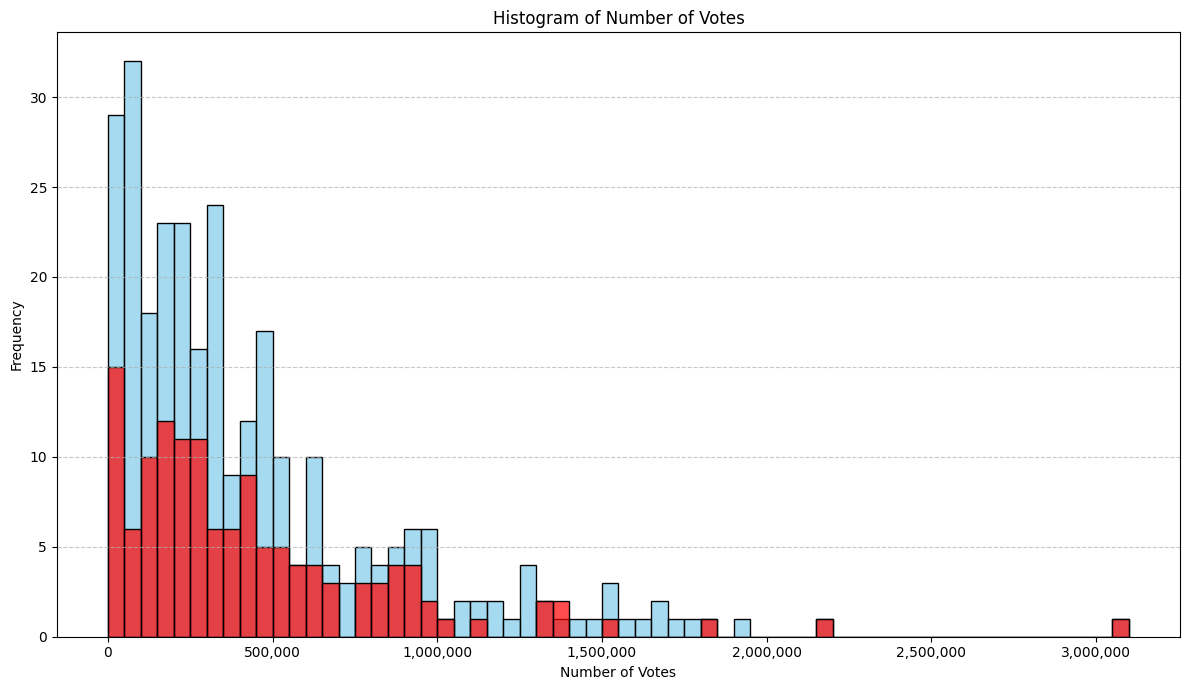

In [43]:
# Calculate maximum for binning
max_votes = df['Num Votes'].max()

# Custom bin width
bin_width = 50000
bins = range(0, int(max_votes) + bin_width, bin_width)

plt.figure(figsize=(12, 7))

sns.histplot(df[nowell]['Num Votes'], bins=bins,
             color='skyblue', edgecolor='black',
             label='Nowell')
sns.histplot(df[taylor]['Num Votes'], bins=bins,
             color='red', edgecolor='black',
             alpha=0.7, label='Taylor')

# Format x-axis labels with thousand separators
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.xlabel('Number of Votes')
plt.ylabel('Frequency')
plt.title('Histogram of Number of Votes')

# Add grid
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

<Axes: xlabel='Num Votes Thousands', ylabel='User Rating'>

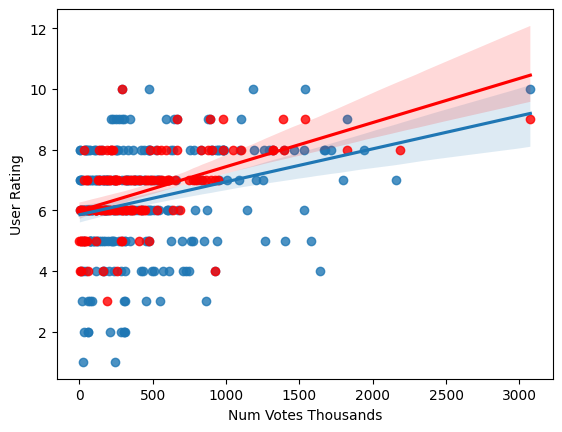

In [44]:
sns.regplot(data=df[nowell], x='Num Votes Thousands', y='User Rating')
sns.regplot(data=df[taylor], x='Num Votes Thousands', y='User Rating', color='red')

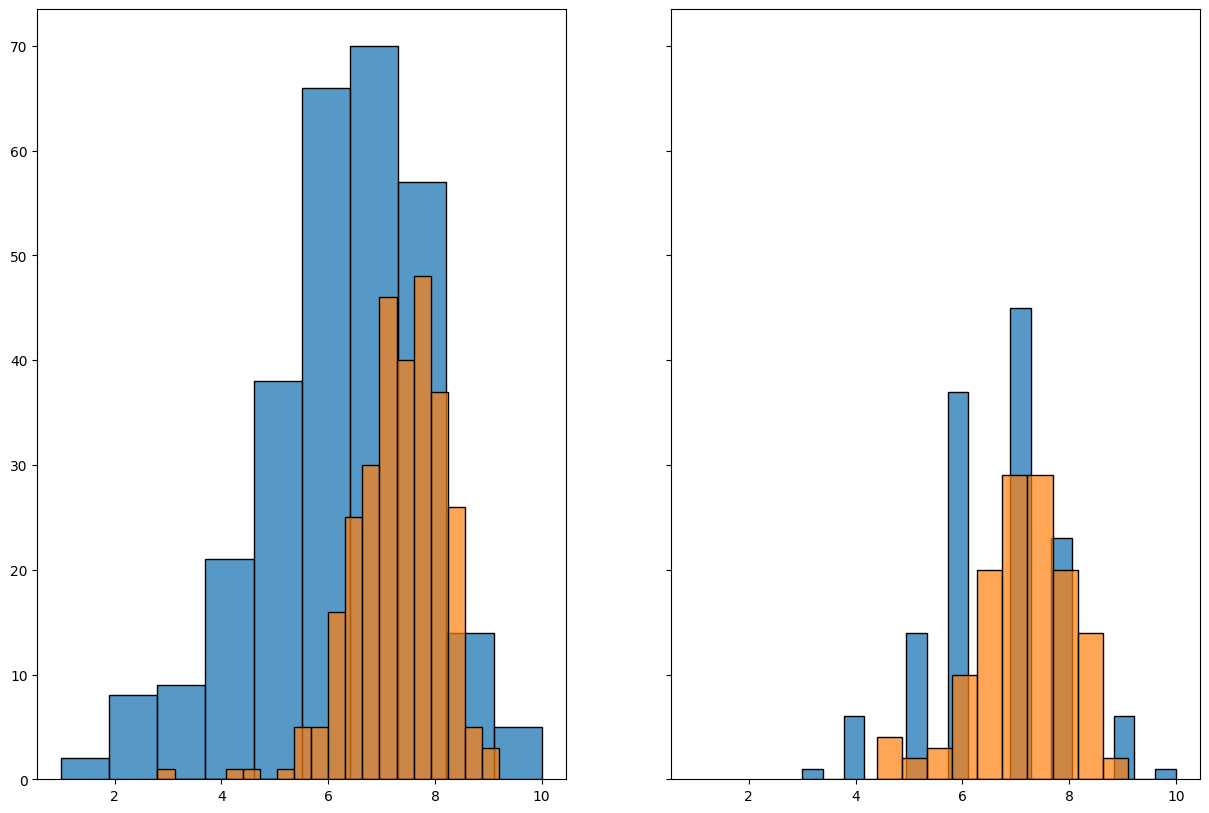

In [45]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 10), sharex=True, sharey=True)
axes = [ax1, ax2]
viewers = [nowell, taylor]

for ax, viewer in zip(axes, viewers):
    sns.histplot(data=df[viewer], x='User Rating',
                ax=ax)
    sns.histplot(data=df[viewer], x='IMDb Rating',
                ax=ax, alpha=0.7)
    ax.set_xlabel(None)
    ax.set_ylabel(None)
    # ax.legend_.remove()

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,10), sharey=True)
# g=sns.histplot(df.loc[nowell]['User Rating'],
#              bins=20, ax=ax1,
#              color='skyblue', edgecolor='black',
#              label = 'Nowell rating', legend=True)
# f=sns.histplot(df['IMDb Rating'],
#                bins=20, color='orange', edgecolor='black',
#                alpha=0.7, ax=ax1,
#                label = 'IMDb Rating', legend=True)

# sns.histplot(df.loc[taylor]['User Rating'],
#              bins=20,  binrange=(1,10),
#              color='red', edgecolor='black',
#              label = 'Taylor rating', ax=ax2)
# sns.histplot(df['IMDb Rating'],
#              bins=20, color='orange', edgecolor='black',
#              alpha=0.7, ax=ax2,
#              label = 'IMDb Rating', legend=True)
# fig.suptitle('Distribution of Ratings')
# fig.supxlabel('Rating')
# fig.supylabel('Frequency')
# ax1.set_xlabel(None)
# ax1.set_ylabel(None)
# ax2.set_xlabel(None)
# ax2.set_ylabel(None)
# fig.legend(loc='upper right', ncols=2)
# plt.tight_layout()
# plt.show()

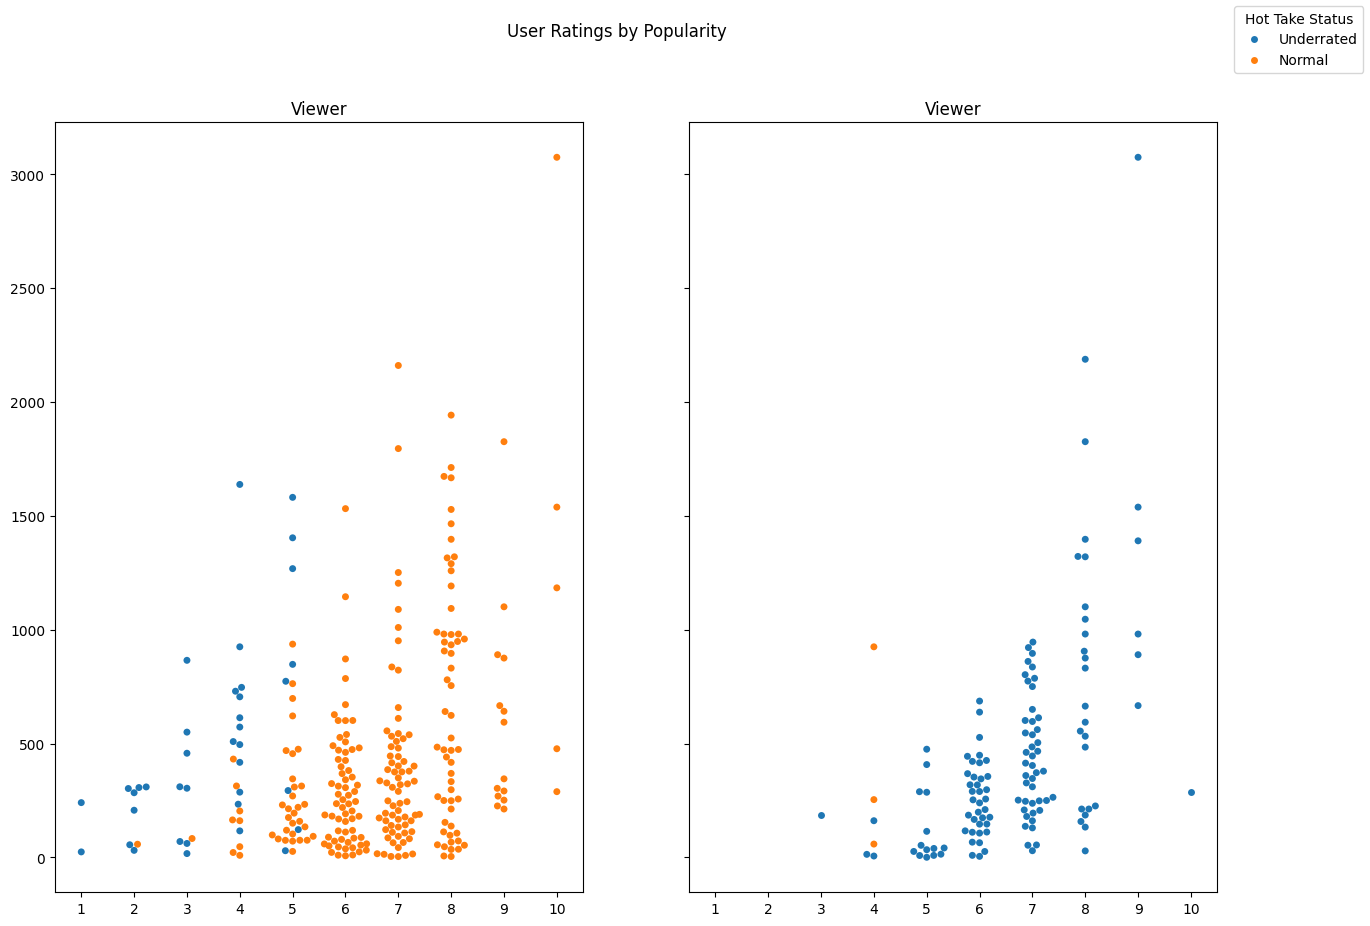

In [46]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 10), sharex=True, sharey=True)
axes = [ax1, ax2]
viewers = [nowell, taylor]

for ax, viewer in zip(axes, viewers):
    sns.swarmplot(data=df[viewer], y='Num Votes Thousands', x='User Rating',
                hue='Hot_Take_Label', ax=ax)
    ax.set_xlabel(None)
    ax.set_ylabel(None)
    ax.legend_.remove()
    ax.set_title(f'{viewer.name.capitalize()}')

fig.suptitle('User Ratings by Popularity')
# fig.supxlabel('IMDb Rating')
# fig.supylabel('User Rating')

fig.legend(*ax1.get_legend_handles_labels(), title='Hot Take Status')
plt.show()

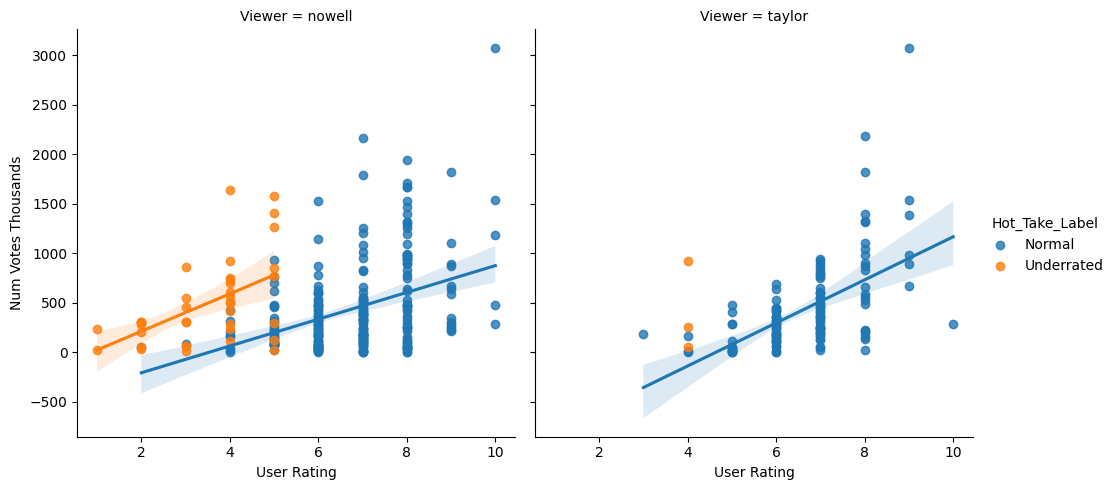

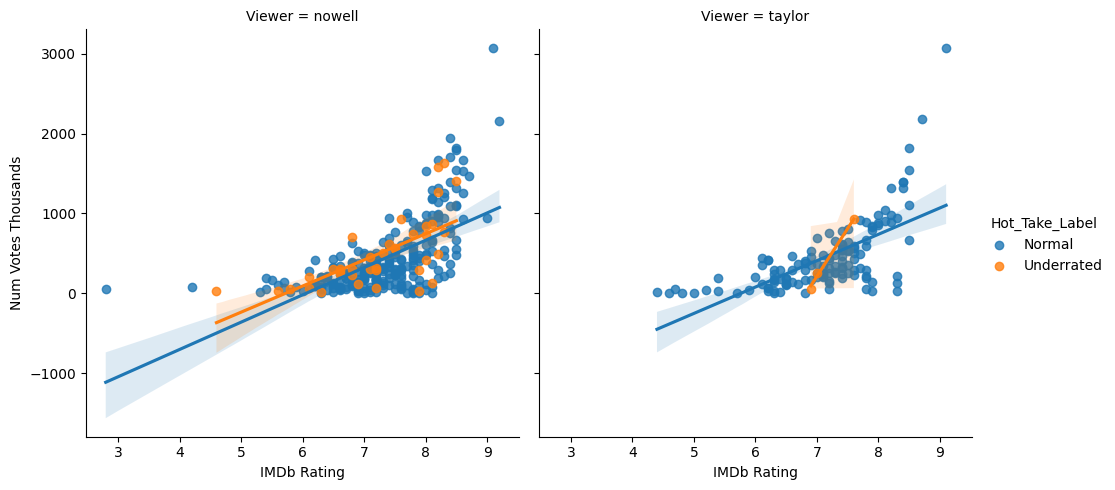

In [47]:
sns.lmplot(data=df, y='Num Votes Thousands', x='User Rating',
           col= 'Viewer', hue='Hot_Take_Label')
sns.lmplot(data=df, y='Num Votes Thousands', x='IMDb Rating',
           col= 'Viewer', hue='Hot_Take_Label')

#### Box Office

In [48]:
df.groupby('Viewer')['Box Office Millions'].describe()

,count,mean,std,min,25%,50%,75%,max
Viewer,,,,,,,,
nowell,257.0,122.111353,147.289065,0.011774,27.467564,70.099045,163.566459,936.662225
taylor,121.0,181.494543,168.422629,0.068372,64.665672,148.974665,226.277068,858.373000


In [49]:
display(df[nowell][movie_details].sort_values(by='Box Office Millions', ascending=False).head(20))
display(df[taylor][movie_details].sort_values(by='Box Office Millions', ascending=False).head(20))

,Title,IMDb Rating,User Rating,Viewer,Release Date,Date Rated,Box Office Millions,Num Votes Thousands
306,Star Wars: Episode VII - The Force Awakens,7.7,7,nowell,2015-12-18,2021-07-25 00:00:00+00:00,936.662225,1009.754
130,Spider-Man: No Way Home,8.2,8,nowell,2021-12-17,2024-08-29 20:13:02+00:00,814.866759,980.924
91,Inside Out 2,7.5,5,nowell,2024-06-14,2024-08-29 20:38:53+00:00,652.980194,230.385
61,Deadpool & Wolverine,7.5,7,nowell,2024-07-26,2024-09-15 13:53:13+00:00,636.745858,532.149
186,Barbie,6.8,6,nowell,2023-07-21,2024-08-09 05:35:52+00:00,636.238421,626.950
190,The Avengers,8.0,8,nowell,2012-05-04,2024-08-09 05:35:25+00:00,623.357910,1528.141
70,Star Wars: Episode VIII - The Last Jedi,6.8,4,nowell,2017-12-15,2024-08-30 06:59:27+00:00,620.181382,705.193
203,The Dark Knight,9.1,10,nowell,2008-07-18,2024-08-09 04:48:41+00:00,534.987076,3074.817
33,Wicked,7.4,7,nowell,2024-11-22,2025-01-15 17:53:04+00:00,473.231120,185.948
154,Star Wars: Episode IV - A New Hope,8.6,6,nowell,1977-05-25,2024-08-29 19:42:04+00:00,460.998507,1531.719


,Title,IMDb Rating,User Rating,Viewer,Release Date,Date Rated,Box Office Millions,Num Votes Thousands
397,Avengers: Endgame,8.4,9,taylor,2019-04-26,2021-12-19 00:00:00+00:00,858.373000,1390.337
131,Spider-Man: No Way Home,8.2,9,taylor,2021-12-17,2021-12-18 00:00:00+00:00,814.866759,980.924
370,Avatar: The Way of Water,7.5,7,taylor,2022-12-16,2023-01-14 00:00:00+00:00,684.075767,546.561
356,Avengers: Infinity War,8.4,8,taylor,2018-04-27,2024-07-11 13:45:20+00:00,678.815482,1321.746
62,Deadpool & Wolverine,7.5,8,taylor,2024-07-26,2024-07-26 09:01:36+00:00,636.745858,532.149
363,Incredibles 2,7.5,7,taylor,2018-06-15,2023-07-02 00:00:00+00:00,608.581744,359.499
343,The Lion King,6.8,5,taylor,2019-07-19,2025-01-05 20:29:47+00:00,543.638043,286.086
204,The Dark Knight,9.1,9,taylor,2008-07-18,2021-08-02 00:00:00+00:00,534.987076,3074.817
34,Wicked,7.4,8,taylor,2024-11-22,2025-02-13 00:39:58+00:00,473.231120,185.948
320,Shrek 2,7.4,7,taylor,2004-05-19,2021-06-01 00:00:00+00:00,444.978202,538.651


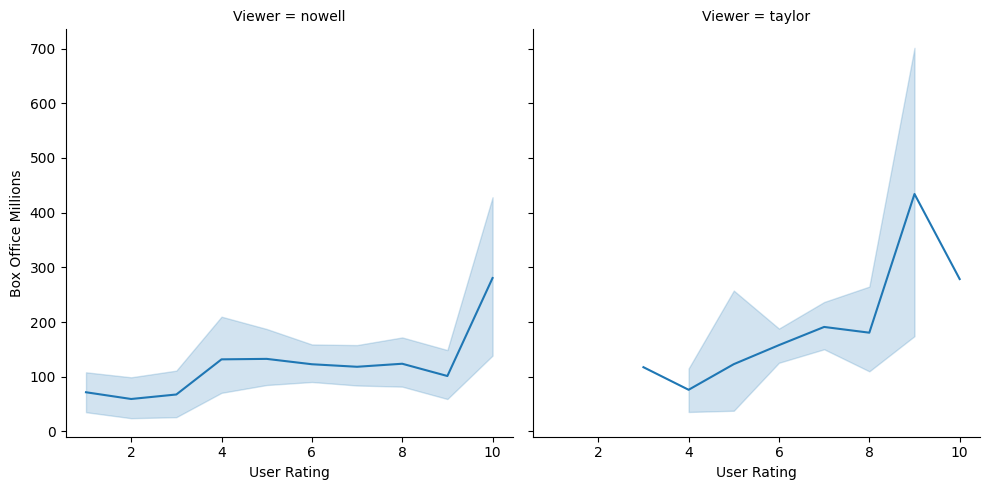

In [50]:
sns.relplot(data=df, y='Box Office Millions', x='User Rating', kind='line',
            col='Viewer')
# ylog_scale = True
# plt.yscale('log')

<Axes: xlabel='IMDb Rating', ylabel='Box Office Millions'>

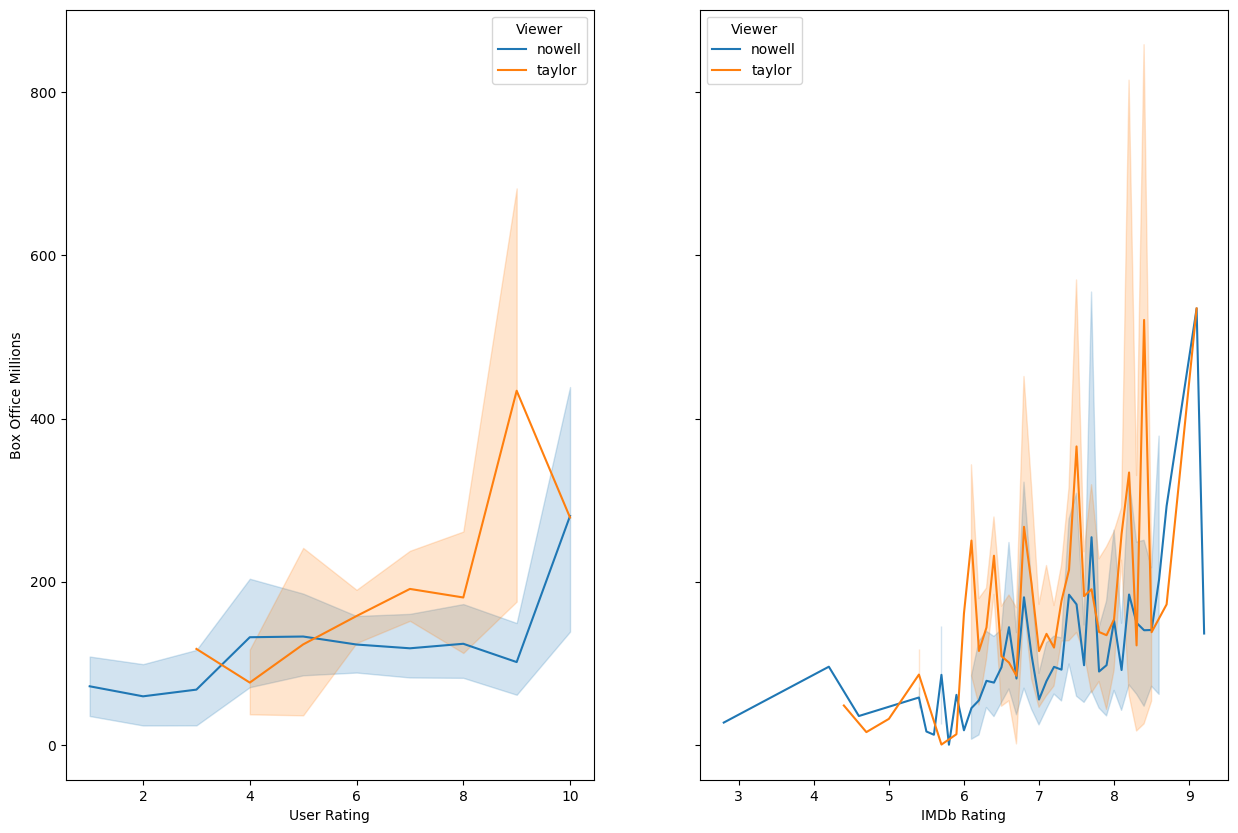

In [51]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,10), sharey=True)
sns.lineplot(data=df, x='User Rating', y='Box Office Millions', hue='Viewer', ax=ax1)
sns.lineplot(data=df, x='IMDb Rating', y='Box Office Millions', hue='Viewer', ax=ax2)

#### Country

In [52]:
country_avg_rating = df_country.groupby(['Country','Viewer']).agg({
    'User Rating': 'mean',
    'IMDb Rating': 'mean',
    'Box Office Millions': 'mean',
    'Num Votes Thousands': 'mean',
    'Title': 'count'
}).rename(columns={'Title':'Count'}).sort_values(by='Count',ascending=False).reset_index()

fig = px.choropleth(country_avg_rating,
                    locations='Country',
                    locationmode='country names',
                    color='Count',
                    hover_name='Country',
                    facet_col='Viewer',
                    hover_data={
        'User Rating': ':.2f',
        'IMDb Rating': ':.2f',
        'Box Office Millions': ':.2f',
        'Num Votes Thousands': ':.2f',
        'Count': True,
        # 'Viewer': True
    },
                    title='Number of Movies by Country',
                    color_continuous_scale='Viridis_r')
fig.show()

C:\Users\nowel\AppData\Local\Temp\ipykernel_25676\2229537502.py:9: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



### Movies Standardised

In [53]:
# Movies standardised

same_movies = pd.merge(df[nowell], df[taylor]['Title'], on='Title', how='inner')

same_movies.shape
# Only ~50 movies we've both seen so can't correlate our ratings

(52, 38)

In [54]:
print(same_movies['Title'])

0                                   The Favourite
1                            Crazy, Stupid, Love.
2                                   Lilo & Stitch
3                                Django Unchained
4                                         Sinners
5                                          Wicked
6                                  Predestination
7                             The Prince of Egypt
8                          A Quiet Place: Day One
9                            Deadpool & Wolverine
10                                    Blink Twice
11               Once Upon a Time... in Hollywood
12              Kingdom of the Planet of the Apes
13                                       Saltburn
14                                    Oppenheimer
15                   Puss in Boots: The Last Wish
16                                     The Batman
17                                    Glass Onion
18                                           Prey
19                        Spider-Man: No Way Home


In [55]:
display(df.groupby('Viewer')['User Rating'].describe())
display(df.groupby('Viewer')['IMDb Rating'].describe())

,count,mean,std,min,25%,50%,75%,max
Viewer,,,,,,,,
nowell,290.0,6.334483,1.717562,1.0,5.0,7.0,8.0,10.0
taylor,133.0,6.631579,1.233827,3.0,6.0,7.0,7.0,10.0


,count,mean,std,min,25%,50%,75%,max
Viewer,,,,,,,,
nowell,290.0,7.327586,0.827050,2.8,6.8,7.4,7.9,9.2
taylor,133.0,7.123308,0.889662,4.4,6.5,7.2,7.7,9.1
